# EDA for New Occurrence Data

"pt" = Permian-Triassic = Perm_Trias folder

"gl" = Guadilupian-Ladinian = Guad-Ladin folder

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Permian-Triassic Data


## Loading + Filtering + EDA Occs Data

In [194]:
pt_reptilia_all = pd.read_excel("Perm-Trias/occs_combined/reptilia_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_All_AF_Tiago_combined.xlsx")
pt_reptilia_terr = pd.read_excel("Perm-Trias/occs_combined/reptilia_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_terres_AF_Tiago_combined.xlsx")
pt_synapsida = pd.read_excel("Perm-Trias/occs_combined/synapsida_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_AF_Tiago_combined.xlsx")

# gl_reptilia = pd.read_excel("Guad-Ladin/reptilia_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_terres_MidTria.xlsx")
# gl_synapsida = pd.read_excel("Guad-Ladin/synapsida_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_MidTria.xlsx")

In [195]:
pt_reptilia_all.columns

Index(['occurrence_no', 'occurrence_no_AF', 'id', 'id_seperated', 'expt',
       'Rotated latitude', 'Rotated longitude', 'i_index', 'j_index',
       'Topo. (m)',
       ...
       'geoplate', 'paleoage', 'paleolng', 'paleolat', 'paleomodel2',
       'geoplate2', 'paleoage2', 'paleolng2', 'paleolat2', 'paleomodel3'],
      dtype='object', length=296)

In [196]:

pt_reptilia_all_filtered = pt_reptilia_all[['id', 'occurrence_no', 'occurrence_no_AF', 'Rotated latitude', 'genus', 'age_max', 'age_min', 'Epoch']]
pt_reptilia_terr_filtered = pt_reptilia_terr[['id', 'occurrence_no', 'occurrence_no_AF', 'Rotated latitude', 'genus', 'age_max', 'age_min', 'Epoch']]
pt_synapsida_filtered = pt_synapsida[['id', 'occurrence_no', 'occurrence_no_AF', 'Rotated latitude', 'genus', 'age_max', 'age_min', 'Epoch']]

# Need to add 'id' back in
# gl_reptilia_filtered = gl_reptilia[['id', 'occurrence_no', 'occurrence_no_AF', 'genus', 'age_max', 'age_min']]
# gl_synapsida_filtered = gl_synapsida[['id', 'occurrence_no', 'occurrence_no_AF', 'genus', 'age_max', 'age_min']]

In [197]:
list_filtered_dfs = [pt_reptilia_all_filtered, pt_reptilia_terr_filtered, pt_synapsida_filtered]
                        # ,gl_reptilia_filtered, gl_synapsida_filtered]

list_filtered_dfs_names = ['pt_reptilia_all_filtered', 'pt_reptilia_terr_filtered', 'pt_synapsida_filtered']
                        # ,'gl_reptilia_filtered', 'gl_synapsida_filtered']

# write a loop for 0:len(list_filtered_dfs) to print the name of each dataframe and its description
# and the number of missing values in each column
for i in range(len(list_filtered_dfs)):
    print(f"DataFrame: {list_filtered_dfs_names[i]}")
    print(list_filtered_dfs[i].describe())
    print(list_filtered_dfs[i].isna().sum())
    # Check that occurrence_no_AF is the same as occurrence_no, because the former came from Alex's dataset and the latter from Tiago's dataset.
    # If they're the same we know merging the two datasets happened correctly.
    different_rows = list_filtered_dfs[i].loc[list_filtered_dfs[i]['occurrence_no'] != list_filtered_dfs[i]['occurrence_no_AF']]
    length_different_rows = different_rows.shape[0]
    print(f"Number of rows where 'occurrence_no' and 'occurrence_no_AF' are different: {length_different_rows}")


DataFrame: pt_reptilia_all_filtered
               id  Rotated latitude      age_max      age_min
count  3987.00000       3987.000000  3987.000000  3987.000000
mean   5134.00000        -71.255378   244.115497   234.918219
std    1151.09209        820.651838    22.017241    24.675819
min    3141.00000      -9999.000000   201.400000   199.500000
25%    4137.50000        -47.039270   227.000000   208.500000
50%    5134.00000          1.353064   242.000000   237.000000
75%    6130.50000         27.011270   259.510000   251.902000
max    7127.00000         61.323520   298.900000   293.520000
id                  0
occurrence_no       0
occurrence_no_AF    0
Rotated latitude    0
genus               0
age_max             0
age_min             0
Epoch               0
dtype: int64
Number of rows where 'occurrence_no' and 'occurrence_no_AF' are different: 0
DataFrame: pt_reptilia_terr_filtered
                id  Rotated latitude      age_max      age_min
count  3140.000000       3140.000000  31

## Ages Visualization (Range Plots)

In [198]:
# Custom function to plot age RANGE (x) frequency (y) with log scale
def range_plot(df, df_name, age_max_col='age_max', age_min_col='age_min'):
    # # Count the frequency of each age range
    # df['range'] = df.apply(lambda row: (row['age_max'], row['age_min']), axis=1)
    # frequency = df['range'].value_counts().sort_index()
    
    # Count the frequency of each age range
    df['range'] = df.apply(lambda row: (row[age_max_col], row[age_min_col]), axis=1)
    frequency = df['range'].value_counts().sort_index()
    # Create the plot
    fig, ax = plt.subplots(figsize=(12,6))

    # Plot each range as a horizontal line with log-transformed y-values
    for (age_min, age_max), count in frequency.items():
        ax.plot([age_min, age_max], [np.log(count)] * 2, 'b-', linewidth=2)

    # Set the axis labels and title
    ax.set_xlabel('Age')
    ax.set_ylabel('Log(Frequency)')
    ax.set_title(f'{df_name} Age Range Frequency Plot (Log Scale)')

    # Get the x-axis limits
    x_min, x_max = ax.get_xlim()

    # Create ticks for every 1 unit
    ticks = np.arange(np.ceil(x_min), np.floor(x_max) + 1, 1)
    ax.set_xticks(ticks)

    # Create labels for every 5 units
    labels = [str(int(x)) if x % 5 == 0 else '' for x in ticks]
    ax.set_xticklabels(labels)

    # Invert the x-axis
    ax.invert_xaxis()

    # Add horizontal line at y=log(10)
    ax.axhline(y=np.log(10), color='r', linestyle='--', linewidth=2)

    # Customize y-axis ticks to show original frequency values
    y_ticks = ax.get_yticks()
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'{np.exp(y):.0f}' for y in y_ticks])

    # Add vertical lines at the time-bin x-values
    vertical_lines = [290.1, 283.5, 273, 264.3, 259.5, 252, 247, 242, 237, 227, 217, 208]
    for vline in vertical_lines:
        ax.axvline(x=vline, color='g', linestyle='--', linewidth=1)

    # Show the plot
    plt.tight_layout()
    plt.show()
    plt.close()

    return fig

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_19484\2271861712.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['range'] = df.apply(lambda row: (row[age_max_col], row[age_min_col]), axis=1)


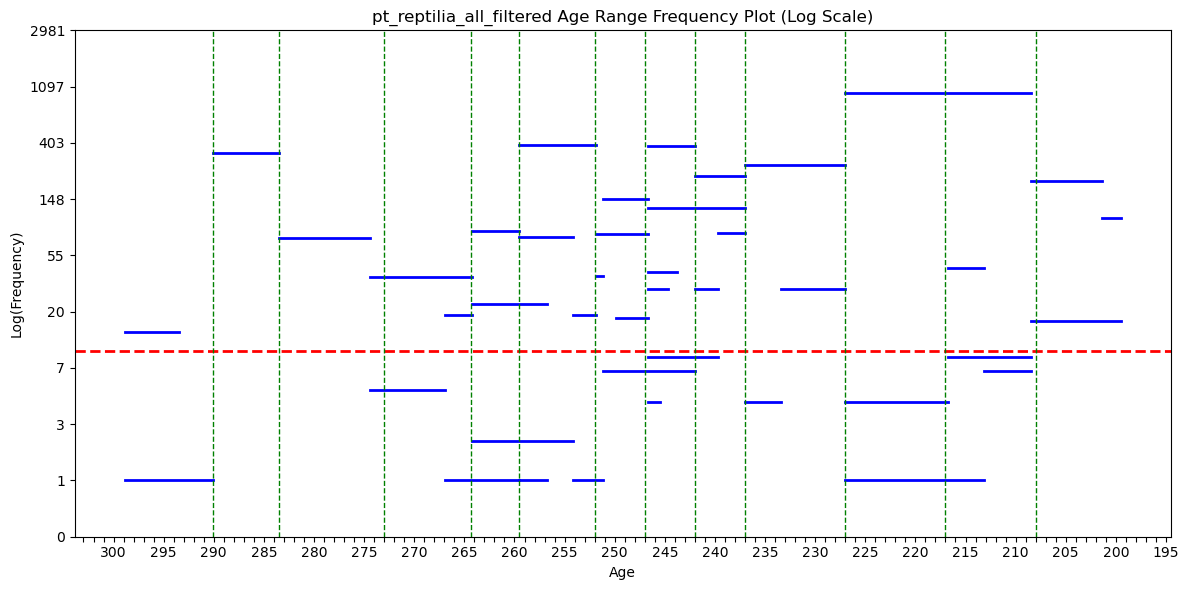

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_19484\2271861712.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['range'] = df.apply(lambda row: (row[age_max_col], row[age_min_col]), axis=1)


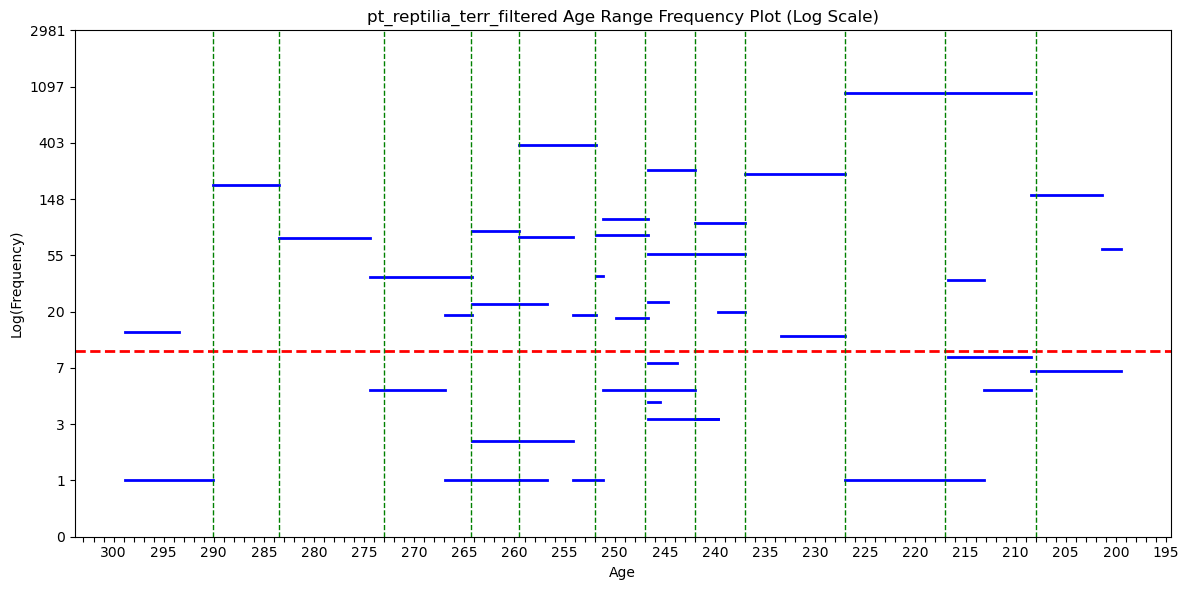

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_19484\2271861712.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['range'] = df.apply(lambda row: (row[age_max_col], row[age_min_col]), axis=1)


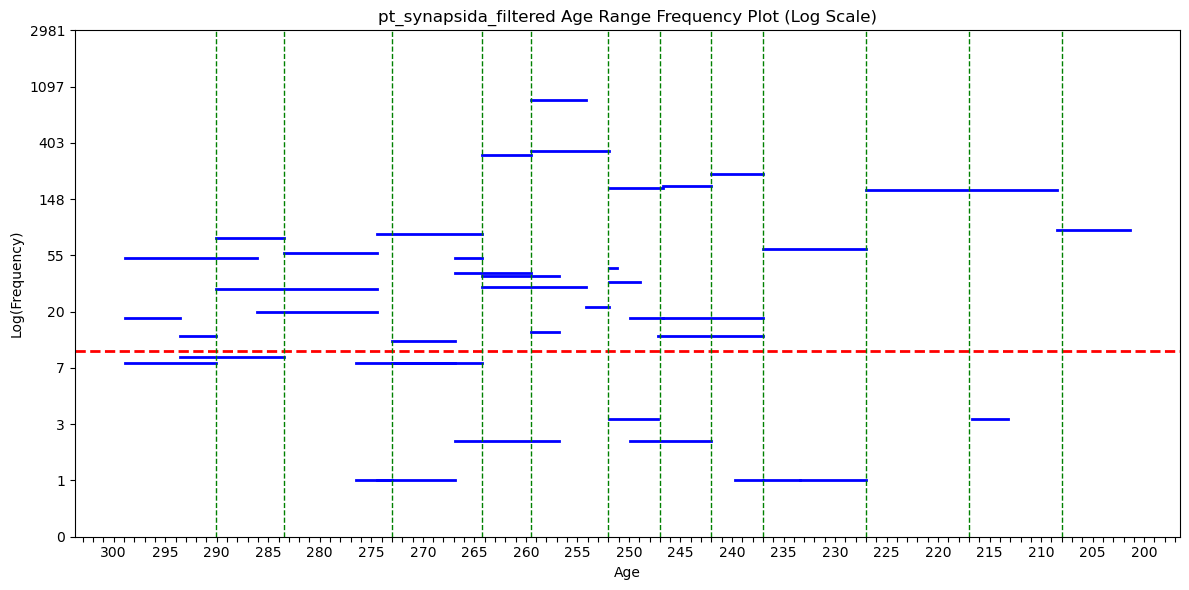

In [199]:
# plot each dataframe using the custom function
# then save the figures

for i in range(len(list_filtered_dfs)):
    fig = range_plot(list_filtered_dfs[i], list_filtered_dfs_names[i])
    fig.savefig(f"Perm-Trias/pt_data_visualizations/{list_filtered_dfs_names[i]}_age_range_frequency_plot.png")


## Dropping non-letter 'genus' strings

In [200]:
# See if there are any non-letters in the 'genus' columns of each dataframe
for i in range(len(list_filtered_dfs)):
    non_letters = list_filtered_dfs[i]['genus'].str.contains(r'[^a-zA-Z]', na=False)
    if non_letters.any():
        print(f"DataFrame: {list_filtered_dfs_names[i]}")
        print(f"Non-letter characters found in 'genus': {list_filtered_dfs[i][non_letters]['genus'].unique()}\n")
    else:
        print(f"DataFrame: {list_filtered_dfs_names[i]} - No non-letter characters found in 'genus'.\n")

DataFrame: pt_reptilia_all_filtered
Non-letter characters found in 'genus': ['new Neotheropoda' 'new Rhynchocephalia' 'Stenoscelida\xa0']

DataFrame: pt_reptilia_terr_filtered
Non-letter characters found in 'genus': ['new Neotheropoda' 'new Rhynchocephalia' 'Stenoscelida\xa0']

DataFrame: pt_synapsida_filtered
Non-letter characters found in 'genus': ['-' 'Bonacynodon ']



In [201]:
# print the rows with non-letter characters in the 'genus' column
for i in range(len(list_filtered_dfs)):
    non_letters = list_filtered_dfs[i]['genus'].str.contains(r'[^a-zA-Z]', na=False)
    if non_letters.any():
        print(f"DataFrame: {list_filtered_dfs_names[i]}")
        print(list_filtered_dfs[i][non_letters])
        print("\n")
    else:
        print(f"DataFrame: {list_filtered_dfs_names[i]} - No non-letter characters found in 'genus'.\n")

DataFrame: pt_reptilia_all_filtered
       id occurrence_no occurrence_no_AF  Rotated latitude  \
974  4115          N363             N363         -46.11636   
975  4116          N364             N364         -46.11636   
979  4120          N503             N503         -46.11636   

                   genus  age_max  age_min           Epoch           range  
974     new Neotheropoda    227.0    208.5  Upper Triassic  (227.0, 208.5)  
975  new Rhynchocephalia    227.0    208.5  Upper Triassic  (227.0, 208.5)  
979        Stenoscelida     227.0    208.5  Upper Triassic  (227.0, 208.5)  


DataFrame: pt_reptilia_terr_filtered
      id occurrence_no occurrence_no_AF  Rotated latitude  \
968  969          N363             N363         -46.11636   
969  970          N364             N364         -46.11636   
973  974          N503             N503         -46.11636   

                   genus  age_max  age_min           Epoch           range  
968     new Neotheropoda    227.0    208.5  Up

In [202]:
# Fixing those

# Make a copy of the filtered dataframes to avoid modifying the original ones
pt_reptilia_all_filtered_spellchecked = pt_reptilia_all_filtered.copy()
pt_reptilia_terr_filtered_spellchecked = pt_reptilia_terr_filtered.copy()
pt_synapsida_filtered_spellchecked = pt_synapsida_filtered.copy()

# Now perform all the cleaning

# Strip the ending space from row with index 979 in pt_reptilia_all_filtered in 'genus' column
pt_reptilia_all_filtered_spellchecked.at[979, 'genus'] = pt_reptilia_all_filtered_spellchecked.at[979, 'genus'].strip()

# Strip the ending space from row with index 973 in pt_reptilia_terr_filtered in 'genus' column
pt_reptilia_terr_filtered_spellchecked.at[973, 'genus'] = pt_reptilia_terr_filtered_spellchecked.at[973, 'genus'].strip()

# Strip the ending space from row with index 2685 and 2686 in pt_synapsida_filtered in 'genus' column
pt_synapsida_filtered_spellchecked.at[2685, 'genus'] = pt_synapsida_filtered_spellchecked.at[2685, 'genus'].strip()
pt_synapsida_filtered_spellchecked.at[2686, 'genus'] = pt_synapsida_filtered_spellchecked.at[2686, 'genus'].strip()

# Delete row with index 370 from pt_synapsida_all_filtered
pt_synapsida_filtered_spellchecked = pt_synapsida_filtered_spellchecked.drop(370)



In [203]:
# Check again

list_filtered_dfs_spellchecked = [pt_reptilia_all_filtered_spellchecked, pt_reptilia_terr_filtered_spellchecked, pt_synapsida_filtered_spellchecked]
list_filtered_dfs_names_spellchecked = ['pt_reptilia_all_filtered_spellchecked', 'pt_reptilia_terr_filtered_spellchecked', 'pt_synapsida_filtered_spellchecked']

# print the rows with non-letter characters in the 'genus' column
for i in range(len(list_filtered_dfs_spellchecked)):
    non_letters = list_filtered_dfs_spellchecked[i]['genus'].str.contains(r'[^a-zA-Z]', na=False)
    if non_letters.any():
        print(f"DataFrame: {list_filtered_dfs_names_spellchecked[i]}")
        print(list_filtered_dfs_spellchecked[i][non_letters])
        print("\n")
    else:
        print(f"DataFrame: {list_filtered_dfs_names_spellchecked[i]} - No non-letter characters found in 'genus'.\n")

DataFrame: pt_reptilia_all_filtered_spellchecked
       id occurrence_no occurrence_no_AF  Rotated latitude  \
974  4115          N363             N363         -46.11636   
975  4116          N364             N364         -46.11636   

                   genus  age_max  age_min           Epoch           range  
974     new Neotheropoda    227.0    208.5  Upper Triassic  (227.0, 208.5)  
975  new Rhynchocephalia    227.0    208.5  Upper Triassic  (227.0, 208.5)  


DataFrame: pt_reptilia_terr_filtered_spellchecked
      id occurrence_no occurrence_no_AF  Rotated latitude  \
968  969          N363             N363         -46.11636   
969  970          N364             N364         -46.11636   

                   genus  age_max  age_min           Epoch           range  
968     new Neotheropoda    227.0    208.5  Upper Triassic  (227.0, 208.5)  
969  new Rhynchocephalia    227.0    208.5  Upper Triassic  (227.0, 208.5)  


DataFrame: pt_synapsida_filtered_spellchecked - No non-letter ch

## PT Latitude -9999 Cleaning


In [204]:
pt_reptilia_all_filtered_spellchecked_lats = pt_reptilia_all_filtered_spellchecked.copy()
pt_reptilia_terr_filtered_spellchecked_lats = pt_reptilia_terr_filtered_spellchecked.copy()
pt_synapsida_filtered_spellchecked_lats = pt_synapsida_filtered_spellchecked.copy()


In [205]:
# Checking for nonsense values in the 'Rotated latitude' column
pt_reptilia_all_filtered_spellchecked_lats['Rotated latitude'].describe(), pt_reptilia_terr_filtered_spellchecked_lats['Rotated latitude'].describe(), pt_synapsida_filtered_spellchecked_lats['Rotated latitude'].describe()

(count    3987.000000
 mean      -71.255378
 std       820.651838
 min     -9999.000000
 25%       -47.039270
 50%         1.353064
 75%        27.011270
 max        61.323520
 Name: Rotated latitude, dtype: float64,
 count    3140.000000
 mean      -23.135116
 std       400.134800
 min     -9999.000000
 25%       -49.043510
 50%         1.353064
 75%        24.956070
 max        61.323520
 Name: Rotated latitude, dtype: float64,
 count    3184.000000
 mean      -45.700334
 std       308.060852
 min     -9999.000000
 25%       -61.365010
 50%       -52.001180
 75%       -15.491353
 max        62.825230
 Name: Rotated latitude, dtype: float64)

### Latitude Visualizations

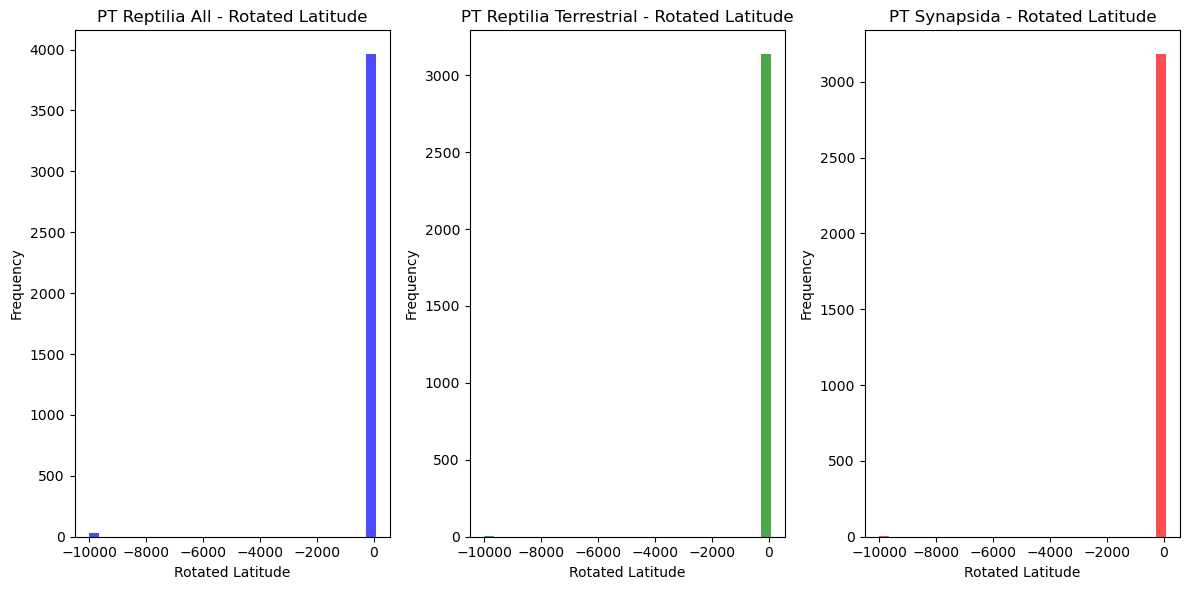

In [206]:
# Visualizing the latitudes
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.hist(pt_reptilia_all_filtered_spellchecked_lats['Rotated latitude'], bins=30, color='blue', alpha=0.7)
plt.title('PT Reptilia All - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 2)    
plt.hist(pt_reptilia_terr_filtered_spellchecked_lats['Rotated latitude'], bins=30, color='green', alpha=0.7)
plt.title('PT Reptilia Terrestrial - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 3)
plt.hist(pt_synapsida_filtered_spellchecked_lats['Rotated latitude'], bins=30, color='red', alpha=0.7)
plt.title('PT Synapsida - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('Perm-Trias/pt_data_visualizations/raw_rotated_latitude_histograms.png')
plt.show()

In [207]:
# Viewing the rows whose latitudes are = -9999

pt_reptilia_9999_lats = pt_reptilia_all_filtered_spellchecked_lats[pt_reptilia_all_filtered_spellchecked_lats['Rotated latitude'] == -9999]
pt_reptilia_terr_9999_lats = pt_reptilia_terr_filtered_spellchecked_lats[pt_reptilia_terr_filtered_spellchecked_lats['Rotated latitude'] == -9999]
pt_synapsida_9999_lats = pt_synapsida_filtered_spellchecked_lats[pt_synapsida_filtered_spellchecked_lats['Rotated latitude'] == -9999]

print("Rows with 'Rotated latitude' = -9999 in pt_reptilia_all_filtered_spellchecked_lats:")
print(pt_reptilia_9999_lats)
print("\nRows with 'Rotated latitude' = -9999 in pt_reptilia_terr_filtered_spellchecked_lats:")
print(pt_reptilia_terr_9999_lats)
print("\nRows with 'Rotated latitude' = -9999 in pt_synapsida_filtered_spellchecked_lats:")
print(pt_synapsida_9999_lats)


Rows with 'Rotated latitude' = -9999 in pt_reptilia_all_filtered_spellchecked_lats:
        id occurrence_no occurrence_no_AF  Rotated latitude            genus  \
691   3832       1108583          1108583           -9999.0     Shastasaurus   
1068  4209        337694           337694           -9999.0   Neusticosaurus   
1069  4210        337705           337705           -9999.0     Cymatosaurus   
1340  4481       1134408          1134408           -9999.0  Californosaurus   
1346  4487       1181747          1181747           -9999.0      Nectosaurus   
1347  4488       1181748          1181748           -9999.0      Nectosaurus   
1348  4489       1181749          1181749           -9999.0     Shastasaurus   
1349  4490       1181750          1181750           -9999.0   Thalattosaurus   
1368  4509       1388419          1388419           -9999.0      Nectosaurus   
1383  4524       1419468          1419468           -9999.0     Shastasaurus   
1384  4525       1419470          14

In [208]:
# After checking with Tiago, we decided to drop the rows with 'Rotated latitude' = -9999
pt_reptilia_all_filtered_spellchecked_lats_dropped = pt_reptilia_all_filtered_spellchecked_lats[pt_reptilia_all_filtered_spellchecked_lats['Rotated latitude'] != -9999]
pt_reptilia_terr_filtered_spellchecked_lats_dropped = pt_reptilia_terr_filtered_spellchecked_lats[pt_reptilia_terr_filtered_spellchecked_lats['Rotated latitude'] != -9999]
pt_synapsida_filtered_spellchecked_lats_dropped = pt_synapsida_filtered_spellchecked_lats[pt_synapsida_filtered_spellchecked_lats['Rotated latitude'] != -9999]

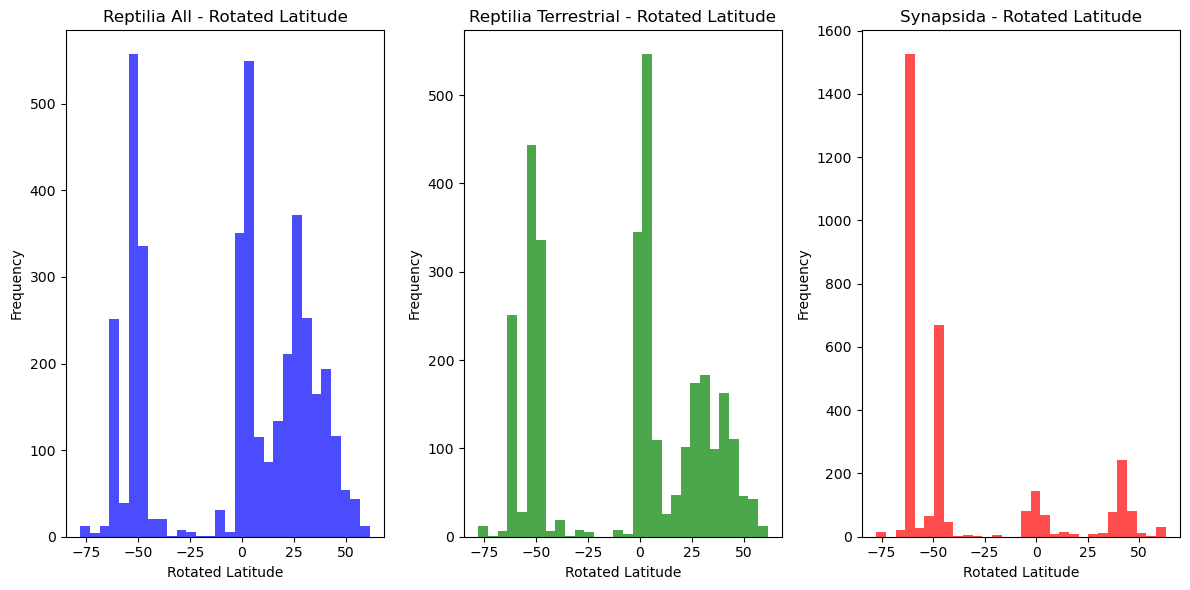

In [209]:
# Visualizing the latitudes now, after having dropped the -9999 values
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.hist(pt_reptilia_all_filtered_spellchecked_lats_dropped['Rotated latitude'], bins=30, color='blue', alpha=0.7)
plt.title('Reptilia All - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 2)    
plt.hist(pt_reptilia_terr_filtered_spellchecked_lats_dropped['Rotated latitude'], bins=30, color='green', alpha=0.7)
plt.title('Reptilia Terrestrial - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 3)
plt.hist(pt_synapsida_filtered_spellchecked_lats_dropped['Rotated latitude'], bins=30, color='red', alpha=0.7)
plt.title('Synapsida - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('Perm-Trias/pt_data_visualizations/cleaned_rotated_latitude_histograms.png')
plt.show()

Note that there's another nice latitude distribution visualization in the "DEFUNCT: PT Latitude Binning ("New" Genera) section below.

In [210]:
pt_reptilia_all_filtered_spellchecked_lats_dropped['Rotated latitude'].describe(), pt_reptilia_terr_filtered_spellchecked_lats_dropped['Rotated latitude'].describe(), pt_synapsida_filtered_spellchecked_lats_dropped['Rotated latitude'].describe()

(count    3960.000000
 mean       -3.566211
 std        36.179317
 min       -77.584400
 25%       -46.558590
 50%         1.357201
 75%        27.011270
 max        61.323520
 Name: Rotated latitude, dtype: float64,
 count    3135.000000
 mean       -7.224646
 std        36.588580
 min       -77.584400
 25%       -49.043510
 50%         1.353064
 75%        24.956070
 max        61.323520
 Name: Rotated latitude, dtype: float64,
 count    3181.000000
 mean      -36.313380
 std        37.978068
 min       -77.584400
 25%       -61.365010
 50%       -52.001180
 75%        -2.980824
 max        62.825230
 Name: Rotated latitude, dtype: float64)

In [211]:
# Save the cleaned dataframes to new csv files
pt_reptilia_all_filtered_spellchecked_lats_dropped.to_csv("Perm-Trias/occs_combined/pt_reptilia_all_cleaned.csv", index=False)
pt_reptilia_terr_filtered_spellchecked_lats_dropped.to_csv("Perm-Trias/occs_combined/pt_reptilia_terr_cleaned.csv", index=False)
pt_synapsida_filtered_spellchecked_lats_dropped.to_csv("Perm-Trias/occs_combined/pt_synapsida_cleaned.csv", index=False)

## Saving PT Occs off as PyRate Input .txts

Saving off data frames up until now, b/c all the rows that need to be dropped have been dropped

In [212]:
# If you want to read it in instead of running all above again, uncomment the following lines:
# pt_reptilia_all_pyrate_input_txt = pd.read_csv("Perm-Trias/occs_combined/pt_reptilia_all_cleaned.csv")
# pt_reptilia_terr_pyrate_input_txt = pd.read_csv("Perm-Trias/occs_combined/pt_reptilia_terr_cleaned.csv")
# pt_synapsida_pyrate_input_txt = pd.read_csv("Perm-Trias/occs_combined/pt_synapsida_cleaned.csv")

In [213]:
cols_dict = {'genus':'Species', 'age_max':'max_age', 'age_min':'min_age'}

pt_reptilia_all_pyrate_input_txt = pt_reptilia_all_filtered_spellchecked_lats_dropped[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
pt_reptilia_all_pyrate_input_txt['Status'] = "extinct"
# Putting the columns in the right order
pt_reptilia_all_pyrate_input_txt = pt_reptilia_all_pyrate_input_txt[['Species', 'Status', 'min_age', 'max_age']]



pt_reptilia_terr_pyrate_input_txt = pt_reptilia_terr_filtered_spellchecked_lats_dropped[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
pt_reptilia_terr_pyrate_input_txt['Status'] = "extinct"
# Putting the columns in the right order
pt_reptilia_terr_pyrate_input_txt = pt_reptilia_terr_pyrate_input_txt[['Species', 'Status', 'min_age', 'max_age']]



pt_synapsida_pyrate_input_txt = pt_synapsida_filtered_spellchecked_lats_dropped[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
pt_synapsida_pyrate_input_txt['Status'] = "extinct"
# Putting the columns in the right order
pt_synapsida_pyrate_input_txt = pt_synapsida_pyrate_input_txt[['Species', 'Status', 'min_age', 'max_age']]

In [214]:
# Checking that new reptilia dataframes are == to the original minus the number of rows that had -9999 lats (i.e. the rows that were dropped)
pt_reptilia_all_filtered.shape[0] - len(pt_reptilia_9999_lats) == pt_reptilia_all_pyrate_input_txt.shape[0], pt_reptilia_terr_filtered.shape[0] - len(pt_reptilia_terr_9999_lats) == pt_reptilia_terr_pyrate_input_txt.shape[0]


(True, True)

In [215]:
# Synapsida dataset should be = original - the number of rows that had -9999 lats (rows that were dropped) 
# - 1 row that was dropped for having no value in 'genus'

(pt_synapsida_filtered.shape[0] - len(pt_synapsida_9999_lats) - 1) == pt_synapsida_pyrate_input_txt.shape[0]

True

In [216]:
pt_reptilia_all_pyrate_input_txt.isna().sum(), pt_reptilia_terr_pyrate_input_txt.isna().sum(), pt_synapsida_pyrate_input_txt.isna().sum()

(Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64,
 Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64,
 Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64)

In [217]:
pt_reptilia_all_pyrate_input_txt.head(), pt_reptilia_terr_pyrate_input_txt.head(), pt_synapsida_pyrate_input_txt.head()

(          Species   Status  min_age  max_age
 0     Icarosaurus  extinct    208.5    227.0
 1        Rutiodon  extinct    208.5    227.0
 2  Trilophosaurus  extinct    208.5    227.0
 3     Postosuchus  extinct    208.5    227.0
 4     Postosuchus  extinct    208.5    227.0,
       Species   Status  min_age  max_age
 0  Vancleavea  extinct    208.5    227.0
 1  Vancleavea  extinct    208.5    227.0
 2  Vancleavea  extinct    208.5    227.0
 3  Vancleavea  extinct    208.5    227.0
 4  Vancleavea  extinct    208.5    227.0,
         Species   Status  min_age  max_age
 0    Dimetrodon  extinct    286.1    298.9
 1    Ophiacodon  extinct    286.1    298.9
 2   Sphenacodon  extinct    286.1    298.9
 3  Edaphosaurus  extinct    286.1    298.9
 4    Ophiacodon  extinct    286.1    298.9)

In [218]:
# Check data types
print(pt_reptilia_all_pyrate_input_txt.dtypes)
print(pt_reptilia_terr_pyrate_input_txt.dtypes)
print(pt_synapsida_pyrate_input_txt.dtypes)

Species     object
Status      object
min_age    float64
max_age    float64
dtype: object
Species     object
Status      object
min_age    float64
max_age    float64
dtype: object
Species     object
Status      object
min_age    float64
max_age    float64
dtype: object


In [219]:
# Check if min_age is ever greater than max_age
print((pt_reptilia_all_pyrate_input_txt['min_age'] > pt_reptilia_all_pyrate_input_txt['max_age']).any())
print((pt_reptilia_terr_pyrate_input_txt['min_age'] > pt_reptilia_terr_pyrate_input_txt['max_age']).any())
print((pt_synapsida_pyrate_input_txt['min_age'] > pt_synapsida_pyrate_input_txt['max_age']).any())


False
False
False


In [220]:
pt_reptilia_all_pyrate_input_txt.info(), pt_reptilia_terr_pyrate_input_txt.info(), pt_synapsida_pyrate_input_txt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3960 entries, 0 to 3986
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  3960 non-null   object 
 1   Status   3960 non-null   object 
 2   min_age  3960 non-null   float64
 3   max_age  3960 non-null   float64
dtypes: float64(2), object(2)
memory usage: 154.7+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 3135 entries, 0 to 3139
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  3135 non-null   object 
 1   Status   3135 non-null   object 
 2   min_age  3135 non-null   float64
 3   max_age  3135 non-null   float64
dtypes: float64(2), object(2)
memory usage: 122.5+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 3181 entries, 0 to 3184
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  3181 non-null   object 
 1   Status   3181 

(None, None, None)

In [221]:
# Saving all off as .txt's
pt_reptilia_all_pyrate_input_txt.to_csv("Perm-Trias/pt_reptilia_all_pyrate_input_txt.txt", sep="\t", index=False)
pt_reptilia_terr_pyrate_input_txt.to_csv("Perm-Trias/pt_reptilia_terr_pyrate_input_txt.txt", sep="\t", index=False)
pt_synapsida_pyrate_input_txt.to_csv("Perm-Trias/pt_synapsida_pyrate_input_txt.txt", sep="\t", index=False)


## DEFUNCT/DO NOT RUN: PT Latitude Binning ("New" Genera)

### UPDATE: We've decided on a different method of taking into account wide-ranging species with large latitudinal ranges. See the sections on creating the BDNN trait file. HOWEVER, there is a **LATITUDINAL RANGE VISUALIZATION** in this section that is useful. Saved off in the pt_data_visuzliations section


I need species-specific trait files, one value per species. However, latitude can range widely within one species, which means averaging latitudes into one value for one species misrepresents the actual geographic distribution of that species. 

I'll need to check the range of latitudes per species, then for species that have a lot of variance in latitudes, I will separate that species into artificial "new" species delineated based off of its latitudinal range, which we have chosen to be 20 degrees

Previous runs done in the "old_occurrence_analyses" folder used the following geological latitude bins:

Latitudinal Bins:
- Arctic Circle: 66 deg 33 mins
- Tropic of Cancer: 23 deg 26 mins
- equator: 0
- Tropic of Capricorn: -23 deg 36 min
- Antarctic Circle: -66 deg 33 min


If 'Rotated Lat' 
- is >66 = Arctic 
- <= 66 & > 23 = Temperate_N
- <= 23 & >= -23 = Tropics
- < -23 & <= -66 = Temperate_S
- < -66 = Antarctic


However, using these lat ranges, there will still be genera whose lat ranges are significantly large (>40 degrees), which still means reducing latitude data to a very coarse resolution, obscuring the effect of latitude as a predictor. 

Below I explore different methods of latitude binning

In [ ]:
# If you want to read it in instead of running all above again, uncomment the following lines:
# pt_reptilia_all_filtered_spellchecked_lats_dropped = pd.read_csv("Perm-Trias/occs_combined/pt_reptilia_all_cleaned.csv")
# pt_reptilia_terr_filtered_spellchecked_lats_dropped = pd.read_csv("Perm-Trias/occs_combined/pt_reptilia_terr_cleaned.csv")
# pt_synapsida_filtered_spellchecked_lats_dropped = pd.read_csv("Perm-Trias/occs_combined/pt_synapsida_cleaned.csv")

In [ ]:
pt_reptilia_all_filtered_spellchecked_lats_dropped['Rotated latitude'].describe(), pt_reptilia_terr_filtered_spellchecked_lats_dropped['Rotated latitude'].describe(), pt_synapsida_filtered_spellchecked_lats_dropped['Rotated latitude'].describe()

(count    3960.000000
 mean       -3.566211
 std        36.179317
 min       -77.584400
 25%       -46.558590
 50%         1.357201
 75%        27.011270
 max        61.323520
 Name: Rotated latitude, dtype: float64,
 count    3135.000000
 mean       -7.224646
 std        36.588580
 min       -77.584400
 25%       -49.043510
 50%         1.353064
 75%        24.956070
 max        61.323520
 Name: Rotated latitude, dtype: float64,
 count    3181.000000
 mean      -36.313380
 std        37.978068
 min       -77.584400
 25%       -61.365010
 50%       -52.001180
 75%        -2.980824
 max        62.825230
 Name: Rotated latitude, dtype: float64)

In all clades/datasets, "Rotated latitude" values span from a minimum of -77.584400 to a maximum of 62.825230

In [73]:
62.825230 - -77.584400

140.40963

In [ ]:
# Checking latitudinal ranges
# Group by genus, then calculate the min, max, and range of latitudes

def check_latitudinal_ranges(df, name):
    lat_ranges = df.groupby('genus')['Rotated latitude'].agg(['min', 'max'])
    lat_ranges['range'] = lat_ranges['max'] - lat_ranges['min']
    print(f"Latitudinal ranges for {name}:")
    print(lat_ranges.sort_values(by='range', ascending=False))
    print("\n")
    print("Stats for latitudinal ranges:")
    print(lat_ranges.describe())
    return lat_ranges  

pt_reptilia_all_lat_ranges = check_latitudinal_ranges(pt_reptilia_all_filtered_spellchecked_lats_dropped, 'pt_reptilia_all')
pt_reptilia_terr_lat_ranges = check_latitudinal_ranges(pt_reptilia_terr_filtered_spellchecked_lats_dropped, 'pt_reptilia_terr')
pt_synapsida_lat_ranges = check_latitudinal_ranges(pt_synapsida_filtered_spellchecked_lats_dropped, 'pt_synapsida')


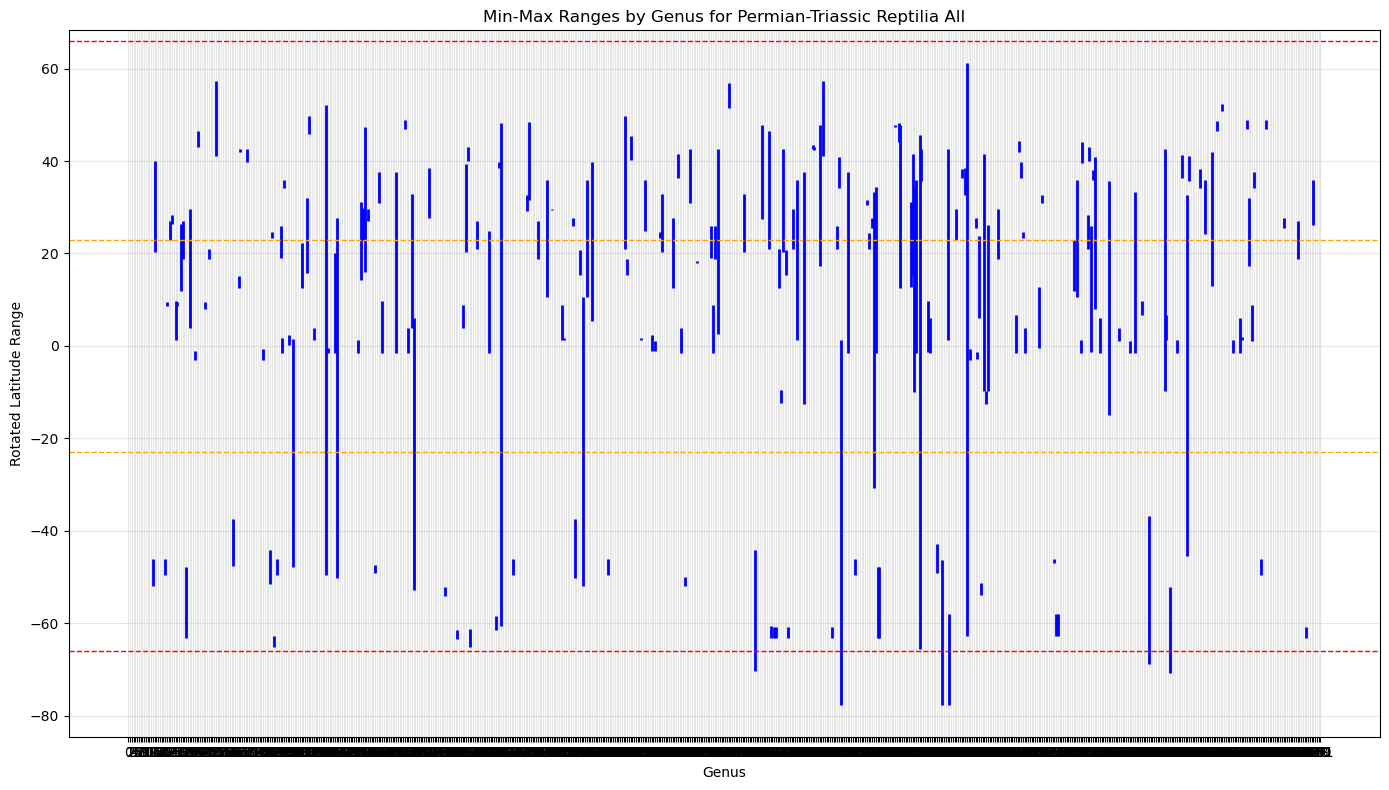

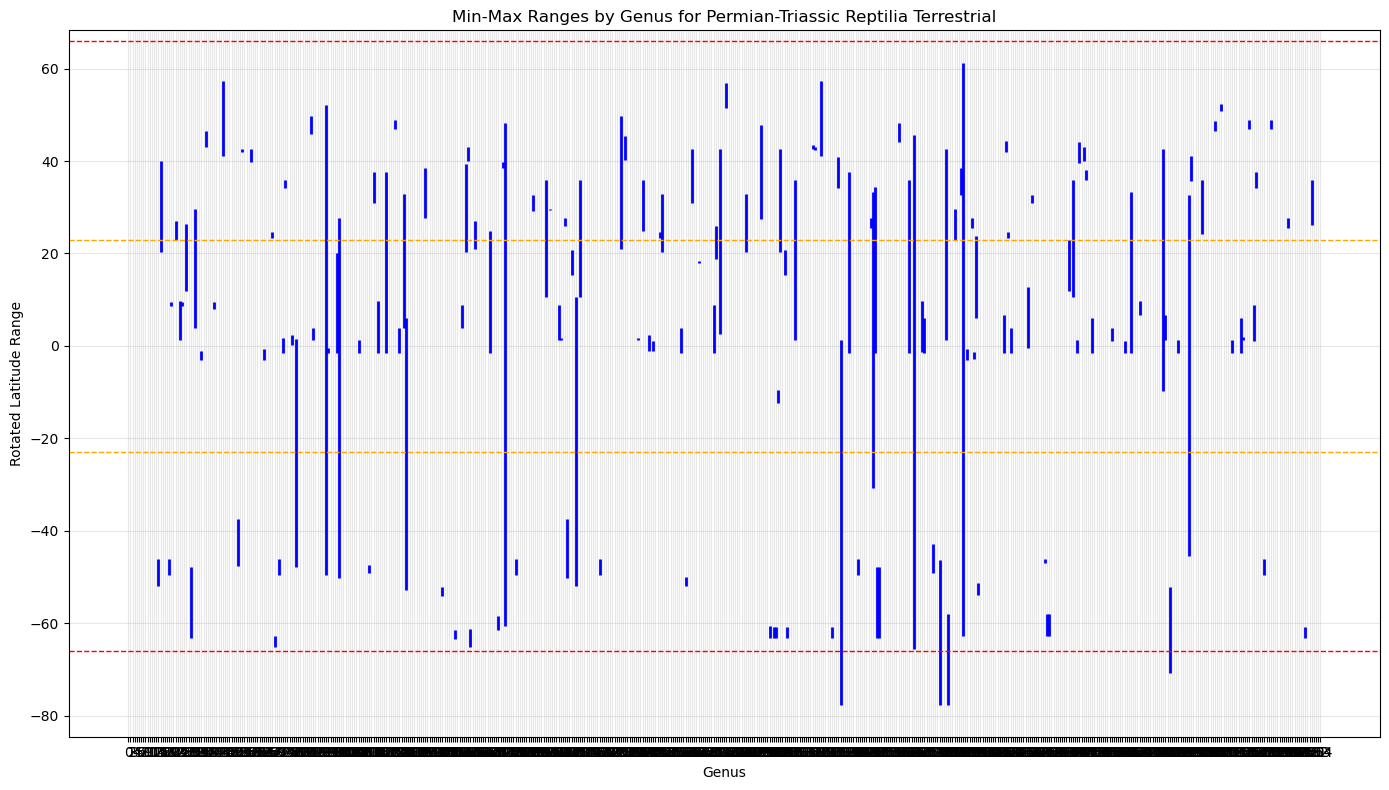

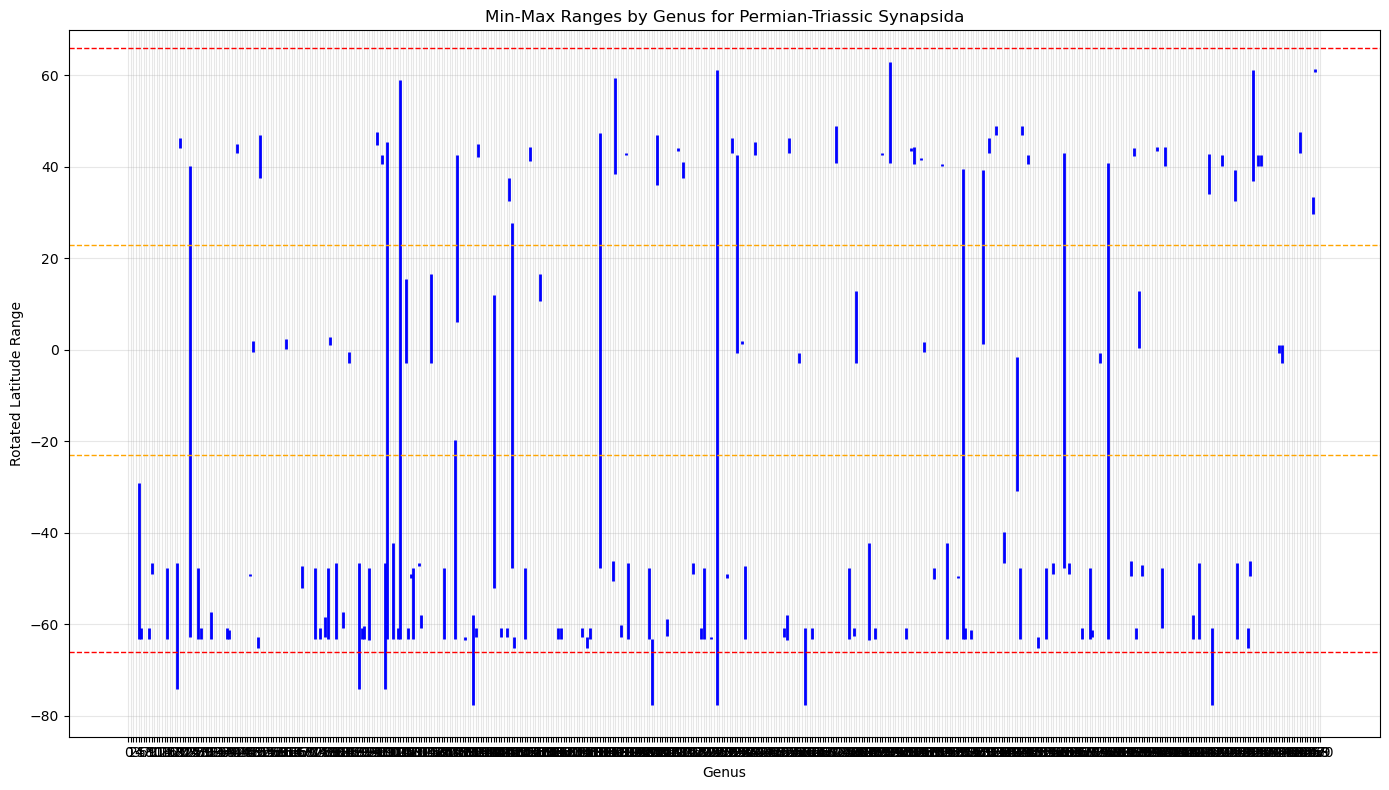

In [ ]:
def plot_genus_ranges_vlines(df, df_name):
    """Plot vertical lines using matplotlib's vlines function"""
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Get x positions (0, 1, 2, ... for each genus)
    x_positions = range(len(df))
    
    # Plot vertical lines from min to max for each genus
    for i, (genus, row) in enumerate(df.iterrows()):
        ax.vlines(x=i, ymin=row['min'], ymax=row['max'], 
                 colors='blue', linewidth=2)
    
    # Set x-axis labels to genus names
    ax.set_xticks(x_positions)
    # ax.set_xticklabels(df.index, rotation=45, ha='right')

    # Set horizontal lines at y = 66, y = 23, y = -23. y = -66
    ax.axhline(y=66, color='red', linestyle='--', linewidth=1)
    ax.axhline(y=23, color='orange', linestyle='--', linewidth=1)
    ax.axhline(y=-23, color='orange', linestyle='--', linewidth=1)
    ax.axhline(y=-66, color='red', linestyle='--', linewidth=1)
    
    # Labels and title
    ax.set_xlabel('Genus')
    ax.set_ylabel('Rotated Latitude Range')
    ax.set_title(f'Min-Max Ranges by Genus for {df_name}')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"Perm-Trias/pt_data_visualizations/{df_name}_lat_ranges_vlines.png", dpi=600)
    plt.show()

plot_genus_ranges_vlines(pt_reptilia_all_lat_ranges, 'Permian-Triassic Reptilia All')
plot_genus_ranges_vlines(pt_reptilia_terr_lat_ranges, 'Permian-Triassic Reptilia Terrestrial')
plot_genus_ranges_vlines(pt_synapsida_lat_ranges, 'Permian-Triassic Synapsida')




In [79]:
pt_reptilia_all_lat_ranges['range'].describe(), pt_reptilia_terr_lat_ranges['range'].describe(), pt_synapsida_lat_ranges['range'].describe()

(count    682.000000
 mean       4.474401
 std       13.293794
 min        0.000000
 25%        0.000000
 50%        0.000000
 75%        2.191812
 max      123.866680
 Name: range, dtype: float64,
 count    555.000000
 mean       4.036313
 std       13.522209
 min        0.000000
 25%        0.000000
 50%        0.000000
 75%        1.708547
 max      123.866680
 Name: range, dtype: float64,
 count    461.000000
 mean       4.733017
 std       15.930623
 min        0.000000
 25%        0.000000
 50%        0.000000
 75%        2.308690
 max      138.801990
 Name: range, dtype: float64)

Trying to ID outliers that might need lat binning via the 1.5IQR rule, for pt_reptilia_all (as a case study). Discovered that using that rule there are a ton more "outliers" than the arbitrary 20 degree lat range we used earlier

In [105]:
series = pt_reptilia_all_lat_ranges['range']
q1 = series.quantile(0.25)
q3 = series.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers_pt_reptilia_all_lat_ranges = series[(series < lower_bound) | (series > upper_bound)]
outliers_pt_reptilia_all_lat_ranges.sort_values(ascending=False)

genus
Proterosuchus       123.866680
Plateosaurus        111.069390
Garjainia           108.998530
Clevosaurus         101.618320
Palacrodon           78.937464
                       ...    
Protanystropheus      6.580790
Prestosuchus          6.239960
Eusaurosphargis       6.130070
Aetosauroides         5.884820
Proterochersis        5.796720
Name: range, Length: 106, dtype: float64

In [ ]:
pt_reptilia_all_filtered_spellchecked_lats_dropped[pt_reptilia_all_filtered_spellchecked_lats_dropped['genus'] == 'Proterochersis']

,id,occurrence_no,occurrence_no_AF,Rotated latitude,genus,age_max,age_min,Epoch,range
676,3817,1099834,1099834,34.47747,Proterochersis,227.0,208.5,Late Triassic,"(227.0, 208.5)"
677,3818,1099923,1099923,32.59323,Proterochersis,227.0,208.5,Late Triassic,"(227.0, 208.5)"
678,3819,1099924,1099924,34.47747,Proterochersis,227.0,208.5,Late Triassic,"(227.0, 208.5)"
709,3850,1334449,1334449,34.47747,Proterochersis,227.0,208.5,Late Triassic,"(227.0, 208.5)"
787,3928,1554602,1554602,38.38995,Proterochersis,227.0,208.5,Late Triassic,"(227.0, 208.5)"


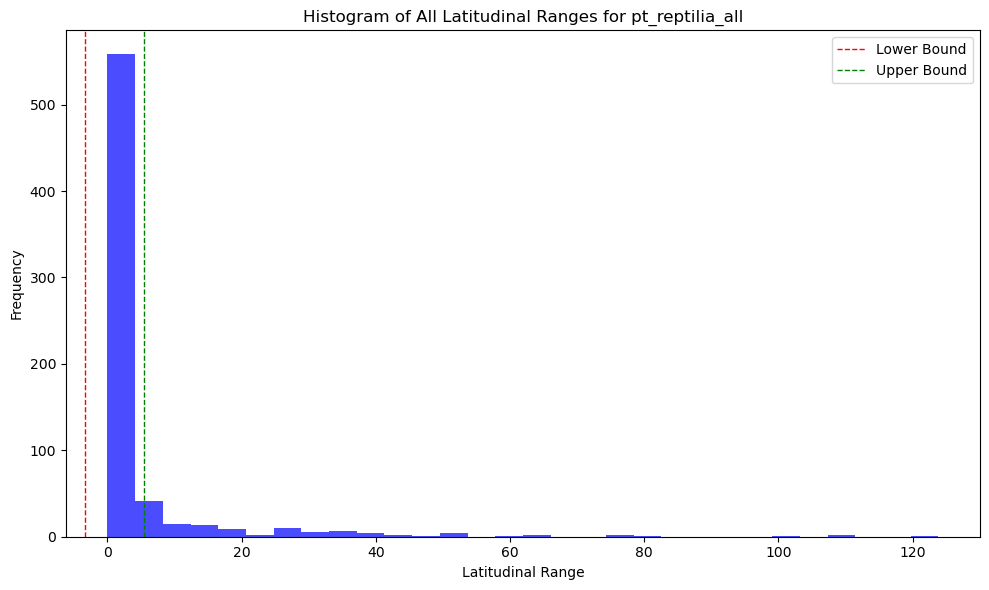

In [121]:
# Plot histogram of latitudinal ranges
plt.figure(figsize=(10, 6))
plt.hist(pt_reptilia_all_lat_ranges['range'], bins=30, color='blue', alpha=0.7)
plt.title('Histogram of All Latitudinal Ranges for pt_reptilia_all')
plt.xlabel('Latitudinal Range')
plt.ylabel('Frequency')
plt.axvline(lower_bound, color='red', linestyle='dashed', linewidth=1, label='Lower Bound')
plt.axvline(upper_bound, color='green', linestyle='dashed', linewidth=1, label='Upper Bound')
plt.legend()
plt.savefig('Perm-Trias/pt_data_visualizations/pt_reptilia_all_lat_ranges_histogram.png')
plt.tight_layout()
plt.show()

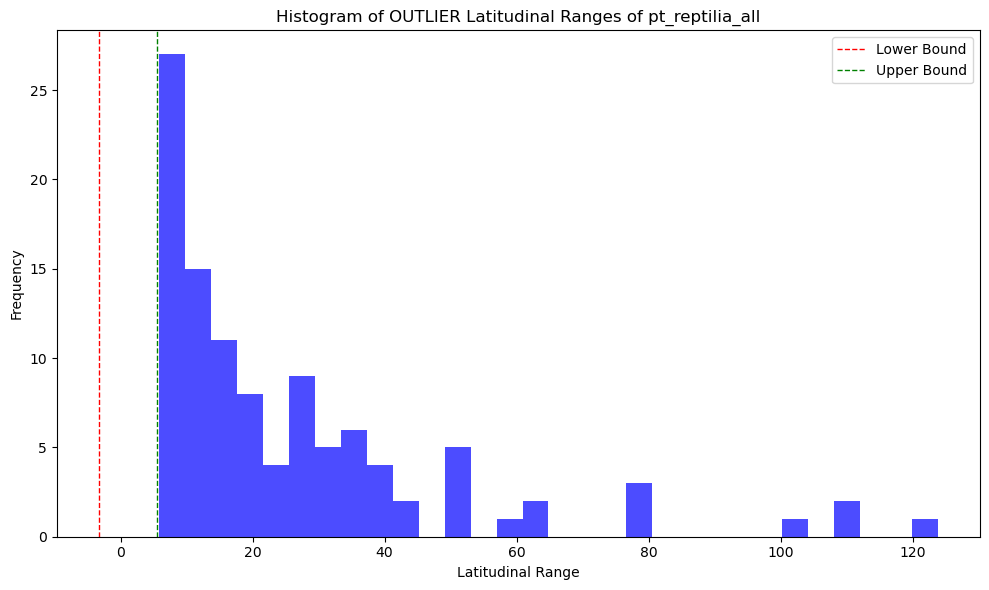

In [120]:
# plot histogram of latitudinal ranges of outliers
outliers_pt_reptilia_all_lat_ranges_df = pt_reptilia_all_lat_ranges[pt_reptilia_all_lat_ranges['range'].isin(outliers_pt_reptilia_all_lat_ranges)]
plt.figure(figsize=(10, 6))
plt.hist(outliers_pt_reptilia_all_lat_ranges_df['range'], bins=30, color='blue', alpha=0.7)
plt.title('Histogram of OUTLIER Latitudinal Ranges of pt_reptilia_all')
plt.xlabel('Latitudinal Range')
plt.ylabel('Frequency')
plt.axvline(lower_bound, color='red', linestyle='dashed', linewidth=1, label='Lower Bound')
plt.axvline(upper_bound, color='green', linestyle='dashed', linewidth=1, label='Upper Bound')
plt.legend()
plt.savefig('Perm-Trias/pt_data_visualizations/outliers_pt_reptilia_all_lat_ranges_histogram.png')
plt.tight_layout()
plt.show()

In [104]:
# Number of genera with latitudinal ranges > 20 degrees
len(pt_reptilia_all_lat_ranges[pt_reptilia_all_lat_ranges['range'] > 20].groupby('genus').size().sort_values(ascending=False))

47

In [107]:
# Number of genera who are outliers in latitudinal range based on IQR method
len(outliers_pt_reptilia_all_lat_ranges_df)

106

In [86]:
# Use 1.5 IQR to find outliers in latitudinal ranges
def find_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    print(f"Outliers in latitudinal ranges for {series}: {outliers}")
    return outliers

pt_reptilia_all_outliers = find_outliers_iqr(pt_reptilia_all_lat_ranges['range'])
pt_reptilia_terr_outliers = find_outliers_iqr(pt_reptilia_terr_lat_ranges['range'])
pt_synapsida_outliers = find_outliers_iqr(pt_synapsida_lat_ranges['range'])
# print("Outliers in latitudinal ranges for pt_reptilia_all:")


Outliers in latitudinal ranges for genus
Abyssomedon            0.00000
Acadiella              0.00000
Acaenasuchus           0.00000
Acallosuchus           0.00000
Acerosodontosaurus     0.00000
                        ...   
Zanclodon              9.85185
Zhongjiania            0.00000
Zupaysaurus            0.00000
new Neotheropoda       0.00000
new Rhynchocephalia    0.00000
Name: range, Length: 682, dtype: float64: genus
Aetosauroides     5.884820
Aetosaurus       19.741860
Angistorhinus     8.357192
Anomoiodon       14.538710
Anshunsaurus      8.228820
                   ...    
Typothorax        7.558767
Utatsusaurus     14.748650
Vancleavea        7.767745
Xinpusaurus       8.228820
Zanclodon         9.851850
Name: range, Length: 106, dtype: float64
Outliers in latitudinal ranges for genus
Abyssomedon            0.00000
Acadiella              0.00000
Acaenasuchus           0.00000
Acallosuchus           0.00000
Acerosodontosaurus     0.00000
                        ...   
Zancl

In [78]:
def lat_ranges_over_20(lat_ranges):
    # Filter for latitudinal ranges greater than 20 degrees and sort by range in descending order
    lat_ranges_over_20 = lat_ranges[lat_ranges['range'] > 20]
    lat_ranges_over_20 = lat_ranges_over_20.sort_values(by='range', ascending=False)
    print(f"Latitudinal ranges over 20 degrees:")
    print(lat_ranges_over_20)
    return lat_ranges_over_20

pt_reptilia_all_lat_ranges_over_20 = lat_ranges_over_20(pt_reptilia_all_lat_ranges)
pt_reptilia_terr_lat_ranges_over_20 = lat_ranges_over_20(pt_reptilia_terr_lat_ranges)
pt_synapsida_lat_ranges_over_20 = lat_ranges_over_20(pt_synapsida_lat_ranges)

Latitudinal ranges over 20 degrees:
                          min        max       range
genus                                               
Proterosuchus      -62.649090  61.217590  123.866680
Plateosaurus       -65.494580  45.574810  111.069390
Garjainia          -60.685250  48.313280  108.998530
Clevosaurus        -49.477130  52.141190  101.618320
Palacrodon         -77.584400   1.353064   78.937464
Teratosaurus       -45.494580  32.593230   78.087810
Coelurosauravus    -50.091960  27.634800   77.726760
Parasuchus         -30.814400  33.314900   64.129300
Hyperodapedon      -52.001180  10.587390   62.588570
Dromomeron         -52.854420   6.088668   58.943088
Tanystropheus       -9.650311  42.706720   52.357031
Psephoderma         -9.650311  41.435560   51.085871
Simosaurus         -14.990220  35.783620   50.773840
Nothosaurus        -12.547470  37.625320   50.172790
Captorhinus        -47.784110   1.521104   49.305214
Placodus            -9.895147  34.449210   44.344357
Proganoche

In [66]:
# Check that all the genera in pt_reptilia_terr_lat_ranges are also in pt_reptilia_all_lat_ranges
pt_reptilia_terr_lat_ranges.index.isin(pt_reptilia_all_lat_ranges.index).all()

True

In [67]:
# LAT BINNING FUNCTION

# Loop through rep_bdnn_dropped and re-name the genuses in the rep_lat_range_20 according to their value in the 'Rotated Lat' column
# which determines which bin they should be in

def lat_binning(df, lat_range_20_list_genus_list):
    df_binned = df.copy()
    for genus in lat_range_20_list_genus_list:
        if genus in df_binned['genus'].values:
            df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] >= 66.5), 'genus'] = genus + '_Arctic'
            df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] >= 23.5) & (df_binned['Rotated Lat'] < 66.5), 'genus'] = genus + '_Temperate_N'
            df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] >= 0) & (df_binned['Rotated Lat'] < 23.5), 'genus'] = genus + '_Tropical_N'
            df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] >= -23.5) & (df_binned['Rotated Lat'] < 0), 'genus'] = genus + '_Tropical_S'
            df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] >= -66.5) & (df_binned['Rotated Lat'] < -23.5), 'genus'] = genus + '_Temperate_S'
            df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] < -66.5), 'genus'] = genus + '_Antarctic'        
    return df_binned

In [ ]:
pt_reptilia_all_binned = lat_binning(pt_reptilia_all_filtered_spellchecked_lats_dropped, pt_reptilia_all_lat_ranges.index.tolist())
pt_reptilia_terr_binned = lat_binning(pt_reptilia_terr_filtered_spellchecked_lats_dropped, pt_reptilia_terr_lat_ranges.index.tolist())
pt_synapsida_binned = lat_binning(pt_synapsida_filtered_spellchecked_lats_dropped, pt_synapsida_lat_ranges.index.tolist())

In [ ]:
# Checking shapes before and after binning, just to make sure we didn't lose any data
# All values should be the same as before binning
pt_reptilia_all_filtered_spellchecked_lats_dropped.shape[0], pt_reptilia_all_binned.shape[0], pt_reptilia_terr_filtered_spellchecked_lats_dropped.shape[0], pt_reptilia_terr_binned.shape[0], pt_synapsida_filtered_spellchecked_lats_dropped.shape[0], pt_synapsida_binned.shape[0]

# Check that the binning worked correctly
# The new dataframes should have more genera than the original ones
print("Genera counts:")
print("Reptilia All Binned:", pt_reptilia_all_binned['genus'].value_counts())
print("Reptilia All Pre-Binning:", pt_reptilia_all_filtered_spellchecked_lats_dropped['genus'].value_counts())
print("Reptilia Terrestrial Binned:", pt_reptilia_terr_binned['genus'].value_counts())
print("Reptilia Terrestrial Pre-Binning:", pt_reptilia_terr_filtered_spellchecked_lats_dropped['genus'].value_counts())
print("Synapsida Binned:", pt_synapsida_binned['genus'].value_counts())
print("Synapsida Pre-Binning:", pt_synapsida_filtered_spellchecked_lats_dropped['genus'].value_counts())


In [ ]:
pd.to_csv(pt_reptilia_all_binned, "Perm-Trias/pt_reptilia_all_lat_binned.csv", index=False)
pd.to_csv(pt_reptilia_terr_binned, "Perm-Trias/pt_reptilia_terr_lat_binned.csv", index=False)
pd.to_csv(pt_synapsida_binned, "Perm-Trias/pt_synapsida_lat_binned.csv", index=False)

# Guadalupian-Ladinian Data

In [236]:
gl_reptilia_all = pd.read_csv("Perm-Trias/occs_combined/pt_reptilia_all_cleaned.csv")
gl_reptilia_terr = pd.read_csv("Perm-Trias/occs_combined/pt_reptilia_terr_cleaned.csv")
gl_synapsida = pd.read_csv("Perm-Trias/occs_combined/pt_synapsida_cleaned.csv")

gl_reptilia_all.head(), gl_reptilia_terr.head(), gl_synapsida.head()

(     id occurrence_no occurrence_no_AF  Rotated latitude           genus  \
 0  3141        146084           146084          6.739012     Icarosaurus   
 1  3142        146085           146085          6.739012        Rutiodon   
 2  3143        149845           149845         -1.470099  Trilophosaurus   
 3  3144        149917           149917         -1.470099     Postosuchus   
 4  3145        149917           149917         -1.470099     Postosuchus   
 
    age_max  age_min          Epoch           range  
 0    227.0    208.5  Late Triassic  (227.0, 208.5)  
 1    227.0    208.5  Late Triassic  (227.0, 208.5)  
 2    227.0    208.5  Late Triassic  (227.0, 208.5)  
 3    227.0    208.5  Late Triassic  (227.0, 208.5)  
 4    227.0    208.5  Late Triassic  (227.0, 208.5)  ,
    id occurrence_no occurrence_no_AF  Rotated latitude       genus  age_max  \
 0   1        557171           557171          1.353064  Vancleavea    227.0   
 1   2        812265           812265          3.83

#### Dealing with one 'Epoch' null in Synapsida

As  you'll see there's one row with a null value in "Epoch". However, its age range falls within the Middle and Upper Triassic, it just spans them both, which is probably why there's a null value. This means I can keep it!

In [237]:
gl_reptilia_all.isna().sum(), gl_reptilia_terr.isna().sum(), gl_synapsida.isna().sum()

(id                  0
 occurrence_no       0
 occurrence_no_AF    0
 Rotated latitude    0
 genus               0
 age_max             0
 age_min             0
 Epoch               0
 range               0
 dtype: int64,
 id                  0
 occurrence_no       0
 occurrence_no_AF    0
 Rotated latitude    0
 genus               0
 age_max             0
 age_min             0
 Epoch               0
 range               0
 dtype: int64,
 id                  0
 occurrence_no       0
 occurrence_no_AF    0
 Rotated latitude    0
 genus               0
 age_max             0
 age_min             0
 Epoch               1
 range               0
 dtype: int64)

In [238]:
gl_synapsida[gl_synapsida['Epoch'].isna()]

,id,occurrence_no,occurrence_no_AF,Rotated latitude,genus,age_max,age_min,Epoch,range
2384,9515,1418754,1418754,-61.37537,Bauria,249.9,242.0,NaN,"(249.9, 242.0)"


In [239]:
gl_synapsida[gl_synapsida['genus'] == 'Bauria']

,id,occurrence_no,occurrence_no_AF,Rotated latitude,genus,age_max,age_min,Epoch,range
2384,9515,1418754,1418754,-61.37537,Bauria,249.9,242.0,NaN,"(249.9, 242.0)"
2446,9578,1418755,1418755,-61.37537,Bauria,246.7,242.0,Middle Triassic,"(246.7, 242.0)"
2465,9597,1332743,1332743,-63.33496,Bauria,246.7,242.0,Middle Triassic,"(246.7, 242.0)"
2517,9649,986757,986757,-61.37537,Bauria,246.7,242.0,Middle Triassic,"(246.7, 242.0)"
2527,9659,923778,923778,-63.33496,Bauria,246.7,242.0,Middle Triassic,"(246.7, 242.0)"
2556,9688,906810,906810,-63.33496,Bauria,246.7,242.0,Middle Triassic,"(246.7, 242.0)"
2558,9690,906808,906808,-61.37537,Bauria,246.7,242.0,Middle Triassic,"(246.7, 242.0)"
2559,9691,906802,906802,-61.37537,Bauria,246.7,242.0,Middle Triassic,"(246.7, 242.0)"
2560,9692,906799,906799,-63.33496,Bauria,246.7,242.0,Middle Triassic,"(246.7, 242.0)"
2561,9693,906797,906797,-61.37537,Bauria,246.7,242.0,Middle Triassic,"(246.7, 242.0)"


In [240]:
# We want to filter for rows that contain only certain values in the "Epoch" column

epochs = ['Guadalupian', 'Lopingian', 'Early Triassic', 'Middle Triassic']

gl_reptilia_all_epochs = gl_reptilia_all[gl_reptilia_all['Epoch'].isin(epochs)]
gl_reptilia_terr_epochs = gl_reptilia_terr[gl_reptilia_terr['Epoch'].isin(epochs)]
gl_synapsida_epochs = gl_synapsida[gl_synapsida['Epoch'].isin(epochs)]


gl_reptilia_all.shape[0], gl_reptilia_all_epochs.shape[0], gl_reptilia_terr.shape[0], gl_reptilia_terr_epochs.shape[0], gl_synapsida.shape[0], gl_synapsida_epochs.shape[0]    


(3960, 1850, 3135, 1343, 3181, 2571)

In [241]:
# Append one row from gl_synapsida to gl_synapsida_epochs
null_row = gl_synapsida.iloc[2384].copy()
gl_synapsida_epochs = pd.concat([gl_synapsida_epochs, null_row.to_frame().T], ignore_index=True)
gl_synapsida_epochs.shape[0], gl_synapsida_epochs.isna().sum(), gl_synapsida_epochs[gl_synapsida_epochs['genus'] == "Bauria"]

(2572,
 id                  0
 occurrence_no       0
 occurrence_no_AF    0
 Rotated latitude    0
 genus               0
 age_max             0
 age_min             0
 Epoch               1
 range               0
 dtype: int64,
         id occurrence_no occurrence_no_AF Rotated latitude   genus age_max  \
 2164  9578       1418755          1418755        -61.37537  Bauria   246.7   
 2183  9597       1332743          1332743        -63.33496  Bauria   246.7   
 2235  9649        986757           986757        -61.37537  Bauria   246.7   
 2245  9659        923778           923778        -63.33496  Bauria   246.7   
 2274  9688        906810           906810        -63.33496  Bauria   246.7   
 2276  9690        906808           906808        -61.37537  Bauria   246.7   
 2277  9691        906802           906802        -61.37537  Bauria   246.7   
 2278  9692        906799           906799        -63.33496  Bauria   246.7   
 2279  9693        906797           906797        -61.37537 

In [242]:
gl_reptilia_all_epochs['Epoch'].value_counts(), gl_reptilia_terr_epochs['Epoch'].value_counts(), gl_synapsida_epochs['Epoch'].value_counts()

(Epoch
 Middle Triassic    929
 Lopingian          485
 Early Triassic     267
 Guadalupian        169
 Name: count, dtype: int64,
 Epoch
 Lopingian          485
 Middle Triassic    468
 Early Triassic     221
 Guadalupian        169
 Name: count, dtype: int64,
 Epoch
 Lopingian          1245
 Guadalupian         596
 Middle Triassic     450
 Early Triassic      280
 Name: count, dtype: int64)

### Latitude Visualizations

Latitudinal ranges for gl_reptilia_all:
                       min        max       range
genus                                            
Proterosuchus   -62.649090  61.217590  123.866680
Garjainia       -60.685250  48.313280  108.998530
Coelurosauravus -50.091960  27.634800   77.726760
Teratosaurus    -45.494580  26.462570   71.957150
Placodus         -9.895147  34.449210   44.344357
...                    ...        ...         ...
Jesairosaurus    -3.863414  -3.863414    0.000000
Jushatyria       46.885000  46.885000    0.000000
Kadimakara      -54.016000 -54.016000    0.000000
Kahneria          1.681402   1.681402    0.000000
Zhongjiania      32.583710  32.583710    0.000000

[335 rows x 3 columns]


Stats for latitudinal ranges:
              min         max       range
count  335.000000  335.000000  335.000000
mean    -1.096047    2.991380    4.087427
std     40.406620   40.690223   12.874720
min    -77.584400  -76.624660    0.000000
25%    -47.784110  -46.558590    0.000000
50

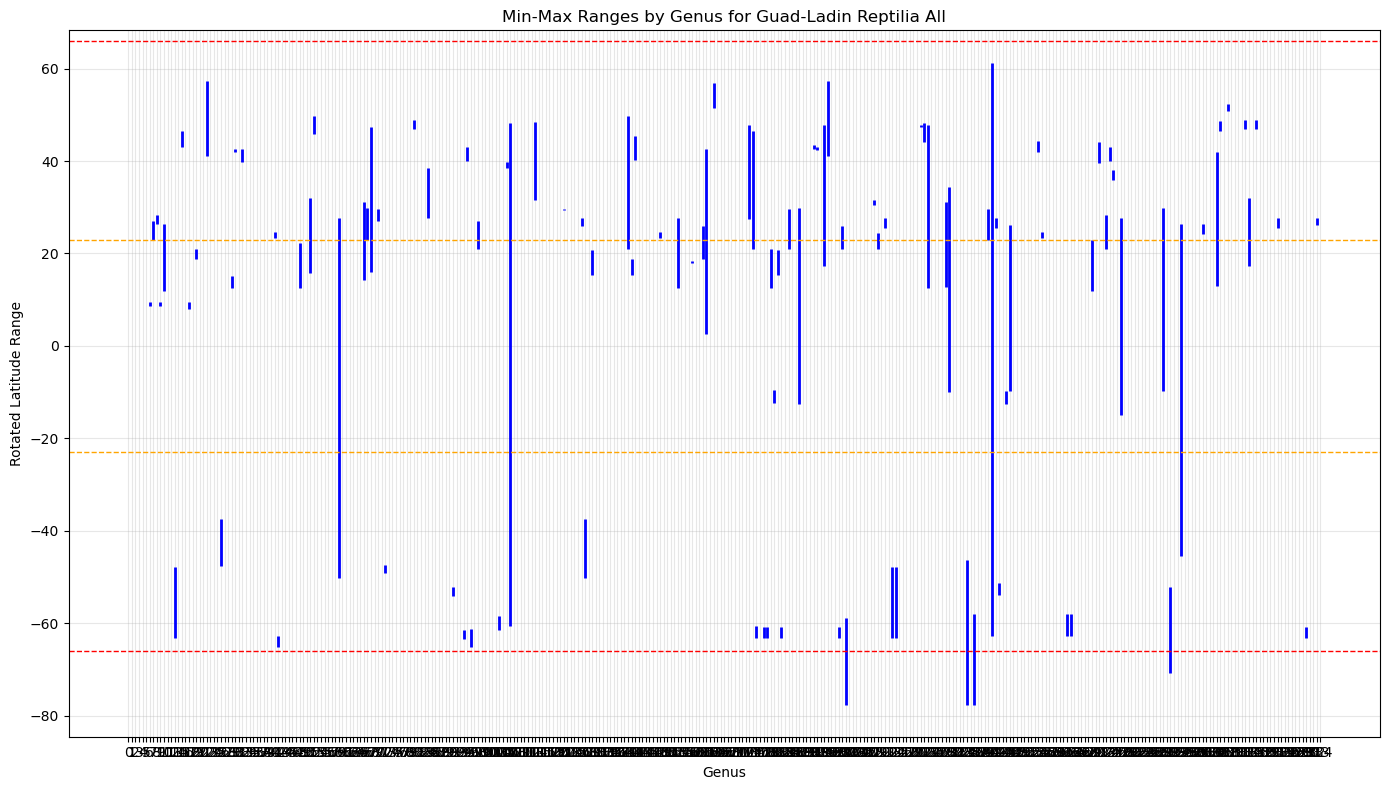

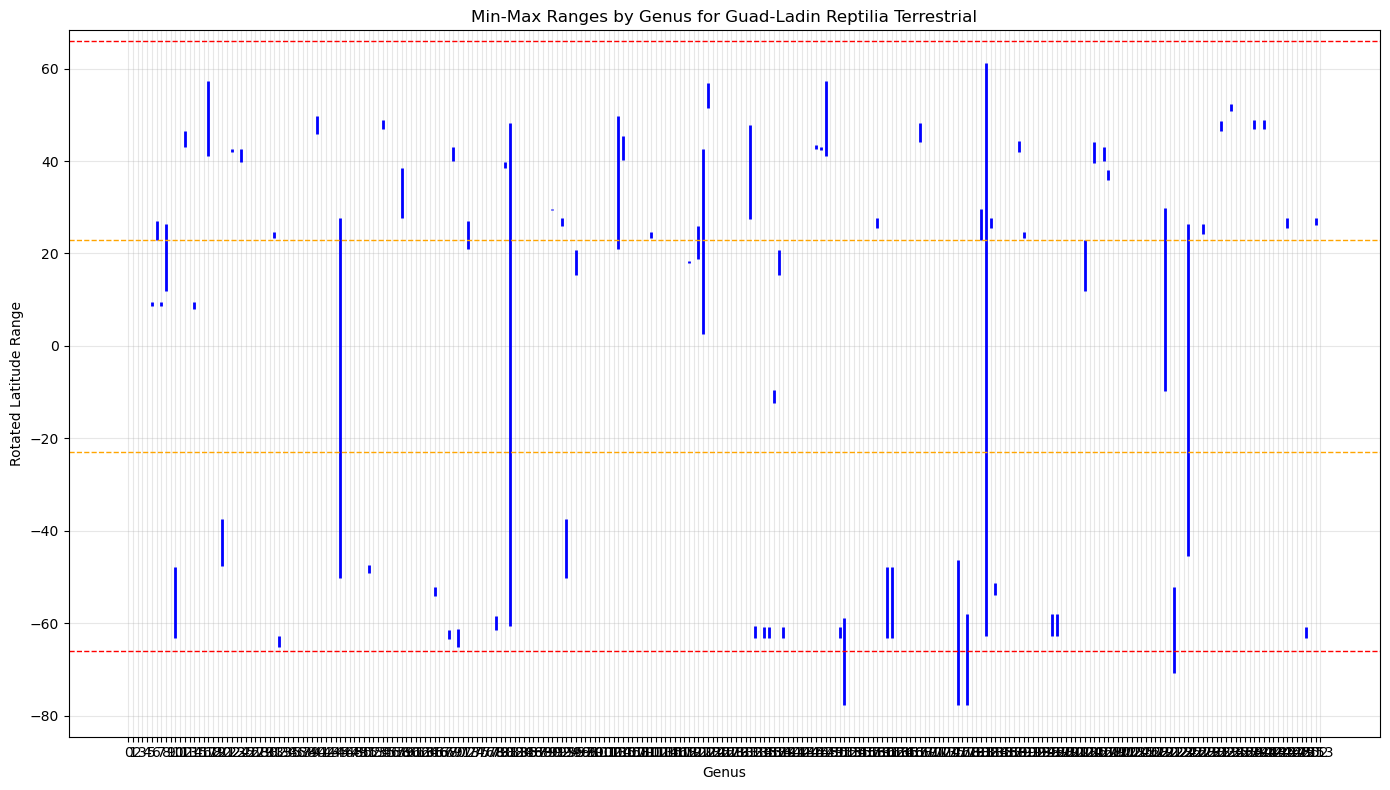

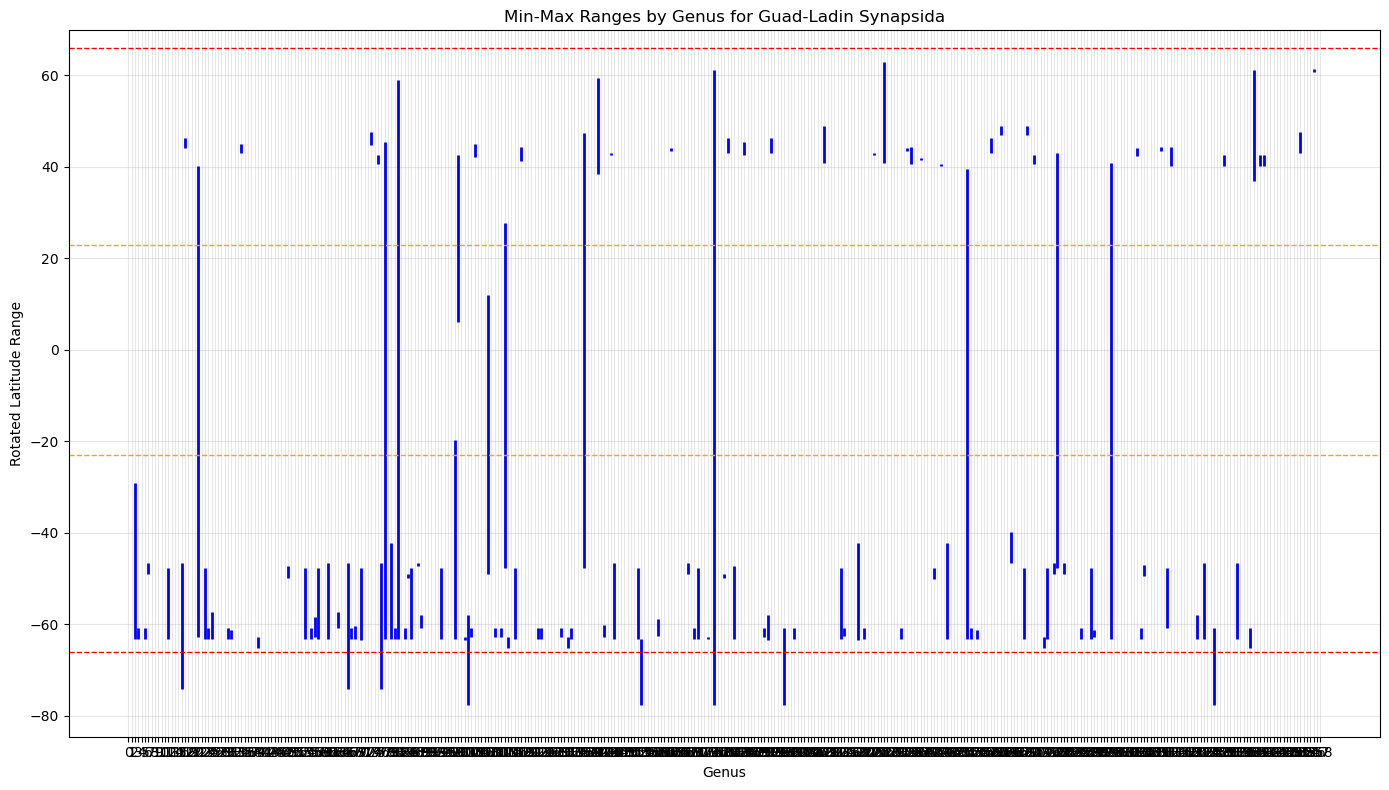

In [247]:
# this function is slightly edited from the DEFUNCT section
def check_latitudinal_ranges(df, name):
    lat_ranges = df.groupby('genus')['Rotated latitude'].agg(['min', 'max'])
    lat_ranges['range'] = lat_ranges['max'] - lat_ranges['min']
    print(f"Latitudinal ranges for {name}:")
    print(lat_ranges.sort_values(by='range', ascending=False))
    print("\n")
    print("Stats for latitudinal ranges:")
    print(lat_ranges.describe())
    return lat_ranges  

gl_reptilia_all_lat_ranges = check_latitudinal_ranges(gl_reptilia_all_epochs, 'gl_reptilia_all')
gl_reptilia_terr_lat_ranges = check_latitudinal_ranges(gl_reptilia_terr_epochs, 'gl_reptilia_terr')
gl_synapsida_lat_ranges = check_latitudinal_ranges(gl_synapsida_epochs, 'gl_synapsida')


def plot_genus_ranges_vlines(df, df_name):
    """Plot vertical lines using matplotlib's vlines function"""
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Get x positions (0, 1, 2, ... for each genus)
    x_positions = range(len(df))
    
    # Plot vertical lines from min to max for each genus
    for i, (genus, row) in enumerate(df.iterrows()):
        ax.vlines(x=i, ymin=row['min'], ymax=row['max'], 
                 colors='blue', linewidth=2)
    
    # Set x-axis labels to genus names
    ax.set_xticks(x_positions)
    # ax.set_xticklabels(df.index, rotation=45, ha='right')

    # Set horizontal lines at y = 66, y = 23, y = -23. y = -66
    ax.axhline(y=66, color='red', linestyle='--', linewidth=1)
    ax.axhline(y=23, color='orange', linestyle='--', linewidth=1)
    ax.axhline(y=-23, color='orange', linestyle='--', linewidth=1)
    ax.axhline(y=-66, color='red', linestyle='--', linewidth=1)
    
    # Labels and title
    ax.set_xlabel('Genus')
    ax.set_ylabel('Rotated Latitude Range')
    ax.set_title(f'Min-Max Ranges by Genus for {df_name}')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"Guad-Ladin/gl_data_visualizations/{df_name}_lat_ranges_vlines.png", dpi=600)
    plt.show()
    
plot_genus_ranges_vlines(gl_reptilia_all_lat_ranges, 'Guad-Ladin Reptilia All')
plot_genus_ranges_vlines(gl_reptilia_terr_lat_ranges, 'Guad-Ladin Reptilia Terrestrial')
plot_genus_ranges_vlines(gl_synapsida_lat_ranges, 'Guad-Ladin Synapsida')

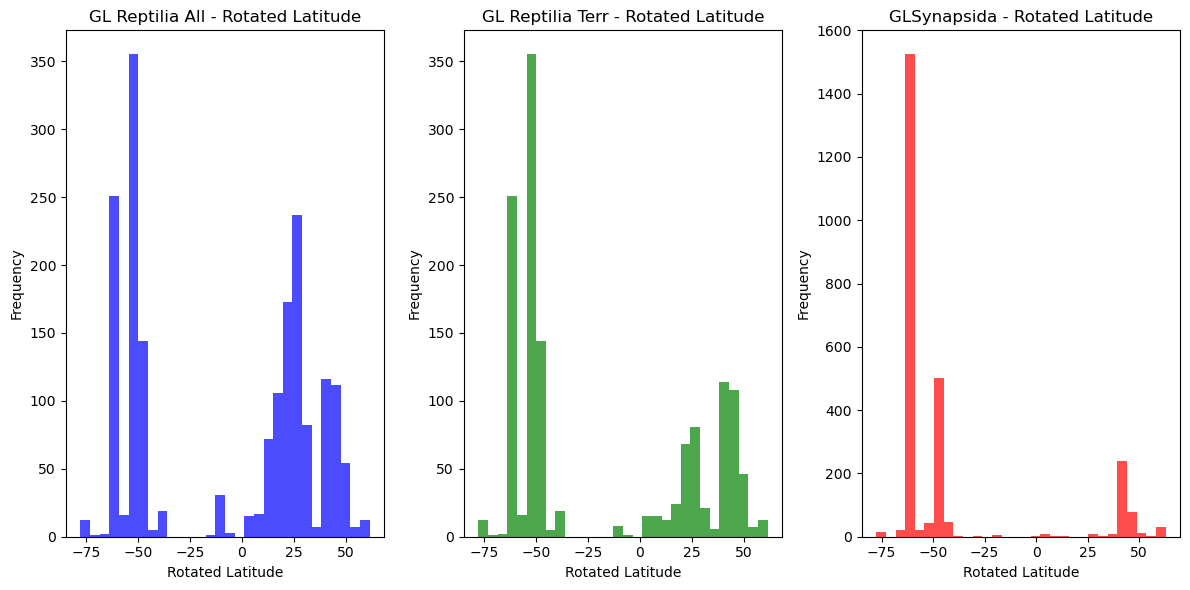

In [164]:
# Visualizing the latitudes
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.hist(gl_reptilia_all_epochs['Rotated latitude'], bins=30, color='blue', alpha=0.7)
plt.title('GL Reptilia All - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 2)
plt.hist(gl_reptilia_terr_epochs['Rotated latitude'], bins=30, color='green', alpha=0.7)
plt.title('GL Reptilia Terr - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 3)    
plt.hist(gl_synapsida_epochs['Rotated latitude'], bins=30, color='red', alpha=0.7)
plt.title('GLSynapsida - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('Guad-Ladin/gl_data_visualizations/cleaned_rotated_latitude_histograms.png')
plt.show()

## Saving GT Occs off as PyRate Input .txts

In [185]:
# Filter to columns

cols_dict = {'genus':'Species', 'age_max':'max_age', 'age_min':'min_age'}

gl_reptilia_all_epochs_filtered = gl_reptilia_all_epochs[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
gl_reptilia_all_epochs_filtered['Status'] = "extinct"
# Putting the columns in the right order
gl_reptilia_all_epochs_filtered = gl_reptilia_all_epochs_filtered[['Species', 'Status', 'min_age', 'max_age']]


gl_reptilia_terr_epochs_filtered = gl_reptilia_terr_epochs[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
gl_reptilia_terr_epochs_filtered['Status'] = "extinct"
# Putting the columns in the right order
gl_reptilia_terr_epochs_filtered = gl_reptilia_terr_epochs_filtered[['Species', 'Status', 'min_age', 'max_age']]

gl_synapsida_epochs_filtered = gl_synapsida_epochs[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
gl_synapsida_epochs_filtered['Status'] = "extinct"
# Putting the columns in the right order
gl_synapsida_epochs_filtered = gl_synapsida_epochs_filtered[['Species', 'Status', 'min_age', 'max_age']]

In [186]:
gl_reptilia_all_epochs_filtered.shape[0], gl_reptilia_terr_epochs_filtered.shape[0], gl_synapsida_epochs_filtered.shape[0]

(1850, 1343, 2572)

In [187]:
gl_reptilia_all_epochs_filtered.head(), gl_reptilia_terr_epochs_filtered.head(), gl_synapsida_epochs_filtered.head()

(              Species   Status  min_age  max_age
 1065   Neusticosaurus  extinct    237.0    246.7
 1066       Mixosaurus  extinct    237.0    246.7
 1067    Omphalosaurus  extinct    237.0    246.7
 1068    Omphalosaurus  extinct    237.0    246.7
 1069  Barracudasaurus  extinct    237.0    246.7,
            Species   Status  min_age  max_age
 1056  Rhombopholis  extinct    237.0    246.7
 1057    Langeronyx  extinct    237.0    246.7
 1058  Teratosaurus  extinct    237.0    246.7
 1059   Macrocnemus  extinct    237.0    246.7
 1060   Macrocnemus  extinct    237.0    246.7,
            Species   Status min_age max_age
 0  Parabradysaurus  extinct   266.9   276.5
 1  Parabradysaurus  extinct   266.9   276.5
 2       Kamagorgon  extinct   266.9   276.5
 3       Kamagorgon  extinct   266.9   276.5
 4      Microsyodon  extinct   266.9   276.5)

In [189]:
gl_reptilia_all_epochs_filtered.info(), gl_reptilia_terr_epochs_filtered.info(), gl_synapsida_epochs_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1850 entries, 1065 to 3959
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  1850 non-null   object 
 1   Status   1850 non-null   object 
 2   min_age  1850 non-null   float64
 3   max_age  1850 non-null   float64
dtypes: float64(2), object(2)
memory usage: 72.3+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 1343 entries, 1056 to 3134
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  1343 non-null   object 
 1   Status   1343 non-null   object 
 2   min_age  1343 non-null   float64
 3   max_age  1343 non-null   float64
dtypes: float64(2), object(2)
memory usage: 52.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2572 entries, 0 to 2571
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Species  2572 non-null   object
 1   Status  

(None, None, None)

In [188]:
gl_reptilia_all_epochs_filtered.describe(), gl_reptilia_terr_epochs_filtered.describe(), gl_synapsida_epochs_filtered.describe()

(           min_age      max_age
 count  1850.000000  1850.000000
 mean    246.079546   251.628532
 std       7.438206     8.127753
 min     237.000000   239.700000
 25%     239.700000   246.700000
 50%     245.100000   251.200000
 75%     251.902000   259.510000
 max     266.900000   274.400000,
            min_age      max_age
 count  1343.000000  1343.000000
 mean    248.411958   254.184648
 std       7.229062     7.934083
 min     237.000000   239.700000
 25%     242.000000   246.700000
 50%     251.200000   251.902000
 75%     251.902000   259.510000
 max     266.900000   274.400000,
           Species   Status  min_age  max_age
 count        2572     2572  2572.00  2572.00
 unique        359        1    13.00    13.00
 top     Diictodon  extinct   254.14   259.51
 freq          182     2572   893.00  1223.00)

In [191]:
gl_reptilia_all_epochs_filtered.isna().sum(), gl_reptilia_terr_epochs_filtered.isna().sum(), gl_synapsida_epochs_filtered.isna().sum()

(Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64,
 Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64,
 Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64)

In [192]:
# Saving them off as .txt's
gl_reptilia_all_epochs_filtered.to_csv("Guad-Ladin/gl_reptilia_all_epochs_filtered.txt", sep="\t", index=False)
gl_reptilia_terr_epochs_filtered.to_csv("Guad-Ladin/gl_reptilia_terr_epochs_filtered.txt", sep="\t", index=False)
gl_synapsida_epochs_filtered.to_csv("Guad-Ladin/gl_synapsida_epochs_filtered.txt", sep="\t", index=False)

## Ages Visualization (Range Plots)

In [ ]:
gl_rep_terr_range_plot = range_plot(gl_reptilia_terr_epochs_filtered, 'gl_reptilia_terr_epochs_filtered', age_max_col = 'max_age', age_min_col = 'min_age')
gl_rep_terr_range_plot.savefig("Guad-Ladin/data_visualizations/gl_reptilia_terr_epochs_filtered_age_range_frequency_plot.png")

gl_synapsida_range_plot = range_plot(gl_synapsida_epochs_filtered, 'gl_synapsida_epochs_filtered', age_max_col = 'max_age', age_min_col = 'min_age')
gl_synapsida_range_plot.savefig("Guad-Ladin/data_visualizations/gl_synapsida_epochs_filtered_age_range_frequency_plot.png")


NameError: name 'range_plot' is not defined

# Predictor Files

## Latitude Data

I'll need:

One row per genus

6 columns:
1. Latitude range for that genus
2. 5 binary flags (1 or 0) for presence in each of the 5 biomes: Arctic (latitude > 66.5), Temperate_North (latitude <= 66.5 and > 23.5), Tropical, Temperate_South, Antarctic




In [4]:
reptilia_all_lats = pd.read_csv("Perm-Trias/occs_combined/pt_reptilia_all_cleaned.csv")
synapsida_lats = pd.read_csv("Perm-Trias/occs_combined/pt_synapsida_cleaned.csv")

reptilia_all_lats.head()


,id,occurrence_no,occurrence_no_AF,Rotated latitude,genus,age_max,age_min,Epoch,range
0,3141,146084,146084,6.739012,Icarosaurus,227.0,208.5,Late Triassic,"(227.0, 208.5)"
1,3142,146085,146085,6.739012,Rutiodon,227.0,208.5,Late Triassic,"(227.0, 208.5)"
2,3143,149845,149845,-1.470099,Trilophosaurus,227.0,208.5,Late Triassic,"(227.0, 208.5)"
3,3144,149917,149917,-1.470099,Postosuchus,227.0,208.5,Late Triassic,"(227.0, 208.5)"
4,3145,149917,149917,-1.470099,Postosuchus,227.0,208.5,Late Triassic,"(227.0, 208.5)"


In [5]:
reptilia_all_lats_filtered = reptilia_all_lats[['genus', 'Rotated latitude']]
synapsida_lats_filtered = synapsida_lats[['genus', 'Rotated latitude']]

reptilia_all_lats_filtered.describe(), synapsida_lats_filtered.describe()

(       Rotated latitude
 count       3960.000000
 mean          -3.566211
 std           36.179317
 min          -77.584400
 25%          -46.558590
 50%            1.357201
 75%           27.011270
 max           61.323520,
        Rotated latitude
 count       3181.000000
 mean         -36.313380
 std           37.978068
 min          -77.584400
 25%          -61.365010
 50%          -52.001180
 75%           -2.980824
 max           62.825230)

In [7]:
reptilia_all_lats_filtered.info(), synapsida_lats_filtered.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   genus             3960 non-null   object 
 1   Rotated latitude  3960 non-null   float64
dtypes: float64(1), object(1)
memory usage: 62.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3181 entries, 0 to 3180
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   genus             3181 non-null   object 
 1   Rotated latitude  3181 non-null   float64
dtypes: float64(1), object(1)
memory usage: 49.8+ KB


(None, None)

### Binary Biome Flags + Lat Ranges

If a genus has even one occurrence with a rotated latitude value that falls within one of the biomes, assign a 1 to the column associated with that biome, indicating that that genus was present in that biome


Biomes:
- Arctic: 'Rotated latitude' >= 66.5
- Temperate North: 23.5 <= 'Rotated latitude' <= 66.5
- Tropical: -23.5 <= 'Rotated latitude' <= 23.5
- Temperate South: -66.5 <= 'Rotated latitude' <= -23.5
- Antarctic: 'Rotated latitude' <= -66.5


In [156]:
# Creating 'Arctic', 'Temperate_N', 'Tropical', 'Temperate_S', 'Antarctic' columns based on the latitudes for each genus
# We're doing this by occurrences first, in case there are genera that skip over biomes (in which case doing biome categorization by latitudinal ranges would not work)

def categorize_latitudes(df):
    df['Arctic'] = df['Rotated latitude'].apply(lambda x: 1 if x >= 66.5 else 0)
    df['Temperate_N'] = df['Rotated latitude'].apply(lambda x: 1 if 23.5 <= x < 66.5 else 0)
    df['Tropical'] = df['Rotated latitude'].apply(lambda x: 1 if -23.5 <= x < 23.5 else 0)
    df['Temperate_S'] = df['Rotated latitude'].apply(lambda x: 1 if -66.5 <= x < -23.5 else 0)
    df['Antarctic'] = df['Rotated latitude'].apply(lambda x: 1 if x < -66.5 else 0)
    return df


In [157]:
reptilia_all_lats_file = categorize_latitudes(reptilia_all_lats_filtered.copy())
synapsida_lats_file = categorize_latitudes(synapsida_lats_filtered.copy())

reptilia_all_lats_file.head(), synapsida_lats_file.head()

(            genus  Rotated latitude  Arctic  Temperate_N  Tropical  \
 0     Icarosaurus          6.739012       0            0         1   
 1        Rutiodon          6.739012       0            0         1   
 2  Trilophosaurus         -1.470099       0            0         1   
 3     Postosuchus         -1.470099       0            0         1   
 4     Postosuchus         -1.470099       0            0         1   
 
    Temperate_S  Antarctic  
 0            0          0  
 1            0          0  
 2            0          0  
 3            0          0  
 4            0          0  ,
           genus  Rotated latitude  Arctic  Temperate_N  Tropical  Temperate_S  \
 0    Dimetrodon          2.480420       0            0         1            0   
 1    Ophiacodon          2.480420       0            0         1            0   
 2   Sphenacodon          2.480420       0            0         1            0   
 3  Edaphosaurus         -2.746595       0            0         1    

In [184]:
# needed reset_index to avoid making 'genus' the index column
reptilia_all_lats_file_groupby = reptilia_all_lats_file.groupby('genus').agg({'Rotated latitude': ['min', 'max'],
    'Arctic': 'sum',
    'Temperate_N': 'sum',
    'Tropical': 'sum',
    'Temperate_S': 'sum',
    'Antarctic': 'sum'}).reset_index()
# Flatten the multi-level columns and rename
reptilia_all_lats_file_groupby.columns = ['genus', 'Rotated_lat_min', 'Rotated_lat_max', 'Arctic', 'Temperate_N', 'Tropical', 'Temperate_S', 'Antarctic']
# Lat range
reptilia_all_lats_file_groupby['lat_range'] = reptilia_all_lats_file_groupby['Rotated_lat_max'] - reptilia_all_lats_file_groupby['Rotated_lat_min']

synapsida_lats_file_groupby = synapsida_lats_file.groupby('genus').agg({'Rotated latitude': ['min', 'max'],
    'Arctic': 'sum',
    'Temperate_N': 'sum',
    'Tropical': 'sum',
    'Temperate_S': 'sum',
    'Antarctic': 'sum'}).reset_index()

# Flatten the multi-level columns and rename
synapsida_lats_file_groupby.columns = ['genus', 'Rotated_lat_min', 'Rotated_lat_max', 'Arctic', 'Temperate_N', 'Tropical', 'Temperate_S', 'Antarctic']
# Lat range
synapsida_lats_file_groupby['lat_range'] = synapsida_lats_file_groupby['Rotated_lat_max'] - synapsida_lats_file_groupby['Rotated_lat_min']

In [185]:
reptilia_all_lats_file_groupby.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   genus            682 non-null    object 
 1   Rotated_lat_min  682 non-null    float64
 2   Rotated_lat_max  682 non-null    float64
 3   Arctic           682 non-null    int64  
 4   Temperate_N      682 non-null    int64  
 5   Tropical         682 non-null    int64  
 6   Temperate_S      682 non-null    int64  
 7   Antarctic        682 non-null    int64  
 8   lat_range        682 non-null    float64
dtypes: float64(3), int64(5), object(1)
memory usage: 48.1+ KB


In [186]:
reptilia_all_lats_file_groupby.head(20)

,genus,Rotated_lat_min,Rotated_lat_max,Arctic,Temperate_N,Tropical,Temperate_S,Antarctic,lat_range
0,Abyssomedon,-0.729992,-0.729992,0,0,1,0,0,0.00000
1,Acadiella,10.587390,10.587390,0,0,1,0,0,0.00000
2,Acaenasuchus,1.353064,1.353064,0,0,8,0,0,0.00000
3,Acallosuchus,1.353064,1.353064,0,0,1,0,0,0.00000
4,Acerosodontosaurus,-50.091960,-50.091960,0,0,0,1,0,0.00000
5,Acleistorhinus,1.059264,1.059264,0,0,1,0,0,0.00000
6,Acrodenta,5.137181,5.137181,0,0,1,0,0,0.00000
7,Actiosaurus,35.783620,35.783620,0,1,0,0,0,0.00000
8,Adamanasuchus,1.353064,1.353064,0,0,1,0,0,0.00000
9,Adelosaurus,26.167200,26.167200,0,1,0,0,0,0.00000


In [188]:
synapsida_lats_file_groupby.head()

,genus,Rotated_lat_min,Rotated_lat_max,Arctic,Temperate_N,Tropical,Temperate_S,Antarctic,lat_range
0,Abajudon,-56.953750,-56.953750,0,0,0,5,0,0.00000
1,Abdalodon,-60.850790,-60.850790,0,0,0,1,0,0.00000
2,Acratophorus,-56.927560,-56.927560,0,0,0,2,0,0.00000
3,Adelobasileus,-1.470099,-1.470099,0,0,1,0,0,0.00000
4,Aelurognathus,-63.159480,-29.134870,0,0,0,30,0,34.02461


In [189]:
# Change binary biome columns so that if the value is > 0, it is 1, otherwise it is 0
reptilia_all_lats_file_groupby['Arctic'] = reptilia_all_lats_file_groupby['Arctic'].apply(lambda x: 1 if x > 0 else 0)
reptilia_all_lats_file_groupby['Temperate_N'] = reptilia_all_lats_file_groupby['Temperate_N'].apply(lambda x: 1 if x > 0 else 0)
reptilia_all_lats_file_groupby['Tropical'] = reptilia_all_lats_file_groupby['Tropical'].apply(lambda x: 1 if x > 0 else 0)
reptilia_all_lats_file_groupby['Temperate_S'] = reptilia_all_lats_file_groupby['Temperate_S'].apply(lambda x: 1 if x > 0 else 0)
reptilia_all_lats_file_groupby['Antarctic'] = reptilia_all_lats_file_groupby['Antarctic'].apply(lambda x: 1 if x > 0 else 0)
synapsida_lats_file_groupby['Arctic'] = synapsida_lats_file_groupby['Arctic'].apply(lambda x: 1 if x > 0 else 0)
synapsida_lats_file_groupby['Temperate_N'] = synapsida_lats_file_groupby['Temperate_N'].apply(lambda x: 1 if x > 0 else 0)
synapsida_lats_file_groupby['Tropical'] = synapsida_lats_file_groupby['Tropical'].apply(lambda x: 1 if x > 0 else 0)
synapsida_lats_file_groupby['Temperate_S'] = synapsida_lats_file_groupby['Temperate_S'].apply(lambda x: 1 if x > 0 else 0)
synapsida_lats_file_groupby['Antarctic'] = synapsida_lats_file_groupby['Antarctic'].apply(lambda x: 1 if x > 0 else 0)

In [190]:
reptilia_all_lats_file_groupby.head(20)

,genus,Rotated_lat_min,Rotated_lat_max,Arctic,Temperate_N,Tropical,Temperate_S,Antarctic,lat_range
0,Abyssomedon,-0.729992,-0.729992,0,0,1,0,0,0.00000
1,Acadiella,10.587390,10.587390,0,0,1,0,0,0.00000
2,Acaenasuchus,1.353064,1.353064,0,0,1,0,0,0.00000
3,Acallosuchus,1.353064,1.353064,0,0,1,0,0,0.00000
4,Acerosodontosaurus,-50.091960,-50.091960,0,0,0,1,0,0.00000
5,Acleistorhinus,1.059264,1.059264,0,0,1,0,0,0.00000
6,Acrodenta,5.137181,5.137181,0,0,1,0,0,0.00000
7,Actiosaurus,35.783620,35.783620,0,1,0,0,0,0.00000
8,Adamanasuchus,1.353064,1.353064,0,0,1,0,0,0.00000
9,Adelosaurus,26.167200,26.167200,0,1,0,0,0,0.00000


In [192]:
reptilia_all_lats_file_groupby.info(), synapsida_lats_file_groupby.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   genus            682 non-null    object 
 1   Rotated_lat_min  682 non-null    float64
 2   Rotated_lat_max  682 non-null    float64
 3   Arctic           682 non-null    int64  
 4   Temperate_N      682 non-null    int64  
 5   Tropical         682 non-null    int64  
 6   Temperate_S      682 non-null    int64  
 7   Antarctic        682 non-null    int64  
 8   lat_range        682 non-null    float64
dtypes: float64(3), int64(5), object(1)
memory usage: 48.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461 entries, 0 to 460
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   genus            461 non-null    object 
 1   Rotated_lat_min  461 non-null    float64
 2   Rotated_lat_max  461 non-null    f

(None, None)

In [193]:
# Making sure we didn't lose any genera in the grouping
len(reptilia_all_lats_file_groupby['genus'].unique()), reptilia_all_lats_file_groupby.shape, len(synapsida_lats_file_groupby['genus'].unique()), synapsida_lats_file_groupby.shape

(682, (682, 9), 461, (461, 9))

In [200]:
# Want to look at all genera with 'range' = 0 
reptilia_range_0 = reptilia_all_lats_file_groupby[reptilia_all_lats_file_groupby['lat_range'] == 0]
reptilia_range_0


,genus,Rotated_lat_min,Rotated_lat_max,Arctic,Temperate_N,Tropical,Temperate_S,Antarctic,lat_range
0,Abyssomedon,-0.729992,-0.729992,0,0,1,0,0,0.0
1,Acadiella,10.587390,10.587390,0,0,1,0,0,0.0
2,Acaenasuchus,1.353064,1.353064,0,0,1,0,0,0.0
3,Acallosuchus,1.353064,1.353064,0,0,1,0,0,0.0
4,Acerosodontosaurus,-50.091960,-50.091960,0,0,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...
676,Yunnanosaurus,52.141190,52.141190,0,1,0,0,0,0.0
678,Zhongjiania,32.583710,32.583710,0,1,0,0,0,0.0
679,Zupaysaurus,-50.497190,-50.497190,0,0,0,1,0,0.0
680,new Neotheropoda,-46.116360,-46.116360,0,0,0,1,0,0.0


In [201]:
# Isolating all occurrences (so from the original reptilia_all_lats_filtered dataframe) of the genera that have a range of 0
reptilia_all_lats_filtered[reptilia_all_lats_filtered['genus'].isin(reptilia_range_0['genus'])].value_counts()


genus                Rotated latitude
Opisthodontosaurus   -0.729992           31
Bradysaurus          -62.751640          30
Fodonyx               21.054390          21
Stenaulorhynchus     -46.558590          21
Lessemsaurus         -50.497190          21
                                         ..
Hescheleria           20.937880           1
Heptasuchus           9.714393            1
Hanosaurus            13.326150           1
Halazhaisuchus        42.978920           1
new Rhynchocephalia  -46.116360           1
Name: count, Length: 472, dtype: int64

In [202]:
# Looking at one of them to make sure every occurrence has the same latitude
reptilia_all_lats_filtered[reptilia_all_lats_filtered['genus'] == 'Opisthodontosaurus']

,genus,Rotated latitude
2154,Opisthodontosaurus,-0.729992
2155,Opisthodontosaurus,-0.729992
2156,Opisthodontosaurus,-0.729992
2157,Opisthodontosaurus,-0.729992
2158,Opisthodontosaurus,-0.729992
2159,Opisthodontosaurus,-0.729992
2160,Opisthodontosaurus,-0.729992
2161,Opisthodontosaurus,-0.729992
2162,Opisthodontosaurus,-0.729992
2163,Opisthodontosaurus,-0.729992


### Z-transformation

In [ ]:
from sklearn.preprocessing import StandardScaler
# Scaling the latitudes

scaler_rep_all_lat_range = StandardScaler()
reptilia_all_lats_file_groupby['lat_range_z_trans'] = scaler_rep_all_lat_range.fit_transform(reptilia_all_lats_file_groupby[['lat_range']])

scaler_syn_lat_range = StandardScaler()
synapsida_lats_file_groupby['lat_range_z_trans'] = scaler_syn_lat_range.fit_transform(synapsida_lats_file_groupby[['lat_range']])


In [250]:
reptilia_all_lats_file_groupby

,genus,Rotated_lat_min,Rotated_lat_max,Arctic,Temperate_N,Tropical,Temperate_S,Antarctic,lat_range,lat_range_z_trans
0,Abyssomedon,-0.729992,-0.729992,0,0,1,0,0,0.00000,-0.336825
1,Acadiella,10.587390,10.587390,0,0,1,0,0,0.00000,-0.336825
2,Acaenasuchus,1.353064,1.353064,0,0,1,0,0,0.00000,-0.336825
3,Acallosuchus,1.353064,1.353064,0,0,1,0,0,0.00000,-0.336825
4,Acerosodontosaurus,-50.091960,-50.091960,0,0,0,1,0,0.00000,-0.336825
...,...,...,...,...,...,...,...,...,...,...
677,Zanclodon,26.116940,35.968790,0,1,0,0,0,9.85185,0.404805
678,Zhongjiania,32.583710,32.583710,0,1,0,0,0,0.00000,-0.336825
679,Zupaysaurus,-50.497190,-50.497190,0,0,0,1,0,0.00000,-0.336825
680,new Neotheropoda,-46.116360,-46.116360,0,0,0,1,0,0.00000,-0.336825


In [251]:
synapsida_lats_file_groupby

,genus,Rotated_lat_min,Rotated_lat_max,Arctic,Temperate_N,Tropical,Temperate_S,Antarctic,lat_range,lat_range_z_trans
0,Abajudon,-56.953750,-56.953750,0,0,0,1,0,0.00000,-0.297425
1,Abdalodon,-60.850790,-60.850790,0,0,0,1,0,0.00000,-0.297425
2,Acratophorus,-56.927560,-56.927560,0,0,0,1,0,0.00000,-0.297425
3,Adelobasileus,-1.470099,-1.470099,0,0,1,0,0,0.00000,-0.297425
4,Aelurognathus,-63.159480,-29.134870,0,0,0,1,0,34.02461,1.840695
...,...,...,...,...,...,...,...,...,...,...
456,Woutersia,37.625320,37.625320,0,1,0,0,0,0.00000,-0.297425
457,Woznikella,29.614780,33.314900,0,1,0,0,0,3.70012,-0.064908
458,Xiyukannemeyeria,60.650370,61.323520,0,1,0,0,0,0.67315,-0.255124
459,Yikezhaogia,42.978920,42.978920,0,1,0,0,0,0.00000,-0.297425


### Backscale.txt

In [271]:
# Making a dataframe by hand, with 'lat_range_z_trans' as the only column, no index, and first row = the original 'lat_range' mean, second row = the original 'lat_range' std

# Named generically because I'll need to add the mean and std of isotopic and BRIDGE data to it later. So it's one backscale txt for reptilia all (since reptilia terr is just a subset of reptilia all) and one for synapsida.
reptilia_all_backscale = pd.DataFrame({
    'lat_range_z_trans': [reptilia_all_lats_file_groupby['lat_range'].mean(), reptilia_all_lats_file_groupby['lat_range'].std()]
}, index=['mean', 'std']).reset_index(drop=True)
synapsida_backscale = pd.DataFrame({
    'lat_range_z_trans': [synapsida_lats_file_groupby['lat_range'].mean(), synapsida_lats_file_groupby['lat_range'].std()]
}, index=['mean', 'std']).reset_index(drop=True)

reptilia_all_backscale, synapsida_backscale

(   lat_range_z_trans
 0           4.474401
 1          13.293794,
    lat_range_z_trans
 0           4.733017
 1          15.930623)

In [257]:
reptilia_all_lats_file_groupby_filtered = reptilia_all_lats_file_groupby[['genus', 'lat_range_z_trans', 'Arctic', 'Temperate_N', 'Tropical', 'Temperate_S', 'Antarctic']]
synapsida_lats_file_groupby_filtered = synapsida_lats_file_groupby[['genus', 'lat_range_z_trans', 'Arctic', 'Temperate_N', 'Tropical', 'Temperate_S', 'Antarctic']]

# Saving the grouped dataframes to txt files
reptilia_all_lats_file_groupby_filtered.to_csv("Perm-Trias/bdnn_trait_files/reptilia_all_lats_file_groupby_filtered.txt", sep="\t", index=False)
synapsida_lats_file_groupby_filtered.to_csv("Perm-Trias/bdnn_trait_files/synapsida_lats_file_groupby_filtered.txt", sep="\t", index=False)

# Also saving as csv files
reptilia_all_lats_file_groupby_filtered.to_csv("Perm-Trias/bdnn_trait_files/reptilia_all_lats_file_groupby_filtered.csv", index=False)
synapsida_lats_file_groupby_filtered.to_csv("Perm-Trias/bdnn_trait_files/synapsida_lats_file_groupby_filtered.csv", index=False)

### How to Handle Occs that are on the cusp of biomes


Occurrences that are at the cusp of biome division lines are a problem if all the occurrences of one unique genus fall very close to the division line, but are still all on one side. If Genus_A for example has occurrences that are all 23.6, and our division line is 23.5, it might be inaccurate to only define Genus_A as present in the Temperate_North biome.

In [ ]:
def explore_lats(df, name):
    print(f"Exploring latitudes for {name}:")
    
    print("\nNumber of unique genera in the Arctic biome, lat > 66")
    arctic_biome = df[df['Rotated latitude'] >= 66]
    print(len(arctic_biome['genus'].unique()))
    

    print("\nNumber of unique genera on the cusp of the 66.5 degree line, 66 < lat < 67")
    cusp_arctic_biome = df[(df['Rotated latitude'] >= 66) & (df['Rotated latitude'] <= 67)]
    cusp_arctic_biome = cusp_arctic_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']).reset_index()
    print(len(cusp_arctic_biome))        
    # Do those genera on the cusp of the Arctic biome have occurrences on both sides of the 66.5 degree line?
    cusp_arctic_biome['Occs on both sides of 66.5'] = False
    if len(cusp_arctic_biome) > 0:
        cusp_arctic_biome_genera = cusp_arctic_biome['genus'].to_list()
        for genus in cusp_arctic_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < 66.5 and occurrences['Rotated latitude'].max() > 66.5:
                cusp_arctic_biome.loc[cusp_arctic_biome['genus'] == genus, 'Occs on both sides of 66.5'] = True
            else:
                cusp_arctic_biome.loc[cusp_arctic_biome['genus'] == genus, 'Occs on both sides of 66.5'] = False
        print("\nLatitude ranges of these cusp genera:")
        print(cusp_arctic_biome)
    

    print("\nNumber of unique genera on the cusp of the 23.5 degree line, 23 < lat < 24")
    cusp_tropic_north_biome = df[(df['Rotated latitude'] >= 23) & (df['Rotated latitude'] <= 24)]
    cusp_tropic_north_biome = cusp_tropic_north_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']).reset_index()
    print(len(cusp_tropic_north_biome))
    # Do those genera on the cusp of the Tropic of Cancer have occurrences on both sides of the 23.5 degree line?
    cusp_tropic_north_biome['Occs on both sides of 23.5'] = False
    if len(cusp_tropic_north_biome) > 0:
        cusp_tropic_north_biome_genera = cusp_tropic_north_biome['genus'].to_list()
        for genus in cusp_tropic_north_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < 23.5 and occurrences['Rotated latitude'].max() > 23.5:
                cusp_tropic_north_biome.loc[cusp_tropic_north_biome['genus'] == genus, 'Occs on both sides of 23.5'] = True
            else:
                cusp_tropic_north_biome.loc[cusp_tropic_north_biome['genus'] == genus, 'Occs on both sides of 23.5'] = False
        print("\nLatitude ranges of these cusp genera:")
        print(cusp_tropic_north_biome)
    # cusp_tropic_north_biome = df[(df['Rotated latitude'] >= 23) & (df['Rotated latitude'] <= 24)]
    # print(len(cusp_tropic_north_biome['genus'].unique()))
    # if len(cusp_tropic_north_biome) > 0:
    #     print(cusp_tropic_north_biome)
    #     print("\nLatitude ranges of these cusp genera:")
    #     print(cusp_tropic_north_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']))
    # # Do those genera on the cusp of the Tropic of Cancer have occurrences on both sides of the 23.5 degree line?
    # if len(cusp_tropic_north_biome) > 0:
    #     cusp_tropic_north_biome_genera = cusp_tropic_north_biome['genus'].unique()
    #     for genus in cusp_tropic_north_biome_genera:
    #         occurrences = df[df['genus'] == genus]
    #         if occurrences['Rotated latitude'].min() < 23.5 and occurrences['Rotated latitude'].max() > 23.5:
    #             print(f"{genus} has occurrences on both sides of the 23.5 degree line.")
    #         else:
    #             print(f"{genus} does NOT have occurrences on both sides of the 23.5 degree line.")
    

    print("\nNumber of unique genera on the cusp of the -23.5 degree line, -24 < lat < -23")
    cusp_tropic_south_biome = df[(df['Rotated latitude'] >= -24) & (df['Rotated latitude'] <= -23)]
    cusp_tropic_south_biome = cusp_tropic_south_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']).reset_index()
    print(len(cusp_tropic_south_biome))
    # Do those genera on the cusp of the Tropic of Capricorn have occurrences on both sides of the -23.5 degree line?
    cusp_tropic_south_biome['Occs on both sides of -23.5'] = False
    if len(cusp_tropic_south_biome) > 0:
        cusp_tropic_south_biome_genera = cusp_tropic_south_biome['genus'].to_list()
        for genus in cusp_tropic_south_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < -23.5 and occurrences['Rotated latitude'].max() > -23.5:
                cusp_tropic_south_biome.loc[cusp_tropic_south_biome['genus'] == genus, 'Occs on both sides of -23.5'] = True
            else:
                cusp_tropic_south_biome.loc[cusp_tropic_south_biome['genus'] == genus, 'Occs on both sides of -23.5'] = False
        print("\nLatitude ranges of these cusp genera:")
        print(cusp_tropic_south_biome)
    # cusp_tropic_south_biome = df[(df['Rotated latitude'] >= -24) & (df['Rotated latitude'] <= -23)]
    # print(len(cusp_tropic_south_biome['genus'].unique()))
    # if len(cusp_tropic_south_biome) > 0:
    #     print(cusp_tropic_south_biome)
    #     print("\nLatitude ranges of these cusp genera:")
    #     print(cusp_tropic_south_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']))
    # # Do those genera on the cusp of the Tropic of Capricorn have occurrences on both sides of the -23.5 degree line?
    # if len(cusp_tropic_south_biome) > 0:
    #     cusp_tropic_south_biome_genera = cusp_tropic_south_biome['genus'].unique()
    #     for genus in cusp_tropic_south_biome_genera:
    #         occurrences = df[df['genus'] == genus]
    #         if occurrences['Rotated latitude'].min() < -23.5 and occurrences['Rotated latitude'].max() > -23.5:
    #             print(f"{genus} has occurrences on both sides of the -23.5 degree line.")
    #         else:
    #             print(f"{genus} does NOT have occurrences on both sides of the -23.5 degree line.")
    

    print("\nNumber of unique genera on the cusp of the -66.5 degree line, -67 < lat < -66")
    cusp_antarctic_biome = df[(df['Rotated latitude'] >= -67) & (df['Rotated latitude'] <= -66)]
    cusp_antarctic_biome = cusp_antarctic_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']).reset_index()
    print(len(cusp_antarctic_biome))
    # Do those genera on the cusp of the Antarctic Circle have occurrences on both sides of the -66.5 degree line?        
    cusp_antarctic_biome['Occs on both sides of -66.5'] = False
    if len(cusp_antarctic_biome) > 0:
        cusp_antarctic_biome_genera = cusp_antarctic_biome['genus'].to_list()
        for genus in cusp_antarctic_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < -66.5 and occurrences['Rotated latitude'].max() > -66.5:
                cusp_antarctic_biome.loc[cusp_antarctic_biome['genus'] == genus, 'Occs on both sides of -66.5'] = True
            else:
                cusp_antarctic_biome.loc[cusp_antarctic_biome['genus'] == genus, 'Occs on both sides of -66.5'] = False
        print("\nLatitude ranges of these cusp genera:")
        print(cusp_antarctic_biome)           
    # cusp_antarctic_biome = df[(df['Rotated latitude'] >= -67) & (df['Rotated latitude'] <= -66)]
    # print(len(cusp_antarctic_biome['genus'].unique()))
    # if len(cusp_antarctic_biome) > 0:
    #     print(cusp_antarctic_biome)
    #     print("\nLatitude ranges of these cusp genera:")
    #     print(cusp_antarctic_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']))
    # # Do those genera on the cusp of the Antarctic Circle have occurrences on both sides of the -66.5 degree line?
    # if len(cusp_antarctic_biome) > 0:
    #     cusp_antarctic_biome_genera = cusp_antarctic_biome['genus'].unique()
    #     for genus in cusp_antarctic_biome_genera:
    #         occurrences = df[df['genus'] == genus]
    #         if occurrences['Rotated latitude'].min() < -66.5 and occurrences['Rotated latitude'].max() > -66.5:
    #             print(f"{genus} has occurrences on both sides of the -66.5 degree line.")
    #         else:
    #             print(f"{genus} does NOT have occurrences on both sides of the -66.5 degree line.")
    
    
    print("\nNumber of unique genera in the Antarctic biome, lat <= -66")
    antarctic_biome = df[df['Rotated latitude'] <= -66]
    print(len(antarctic_biome['genus'].unique()))
    # If any of the above dataframes containing CUSP genera are >=1, print the rows in the dataframe that correspond to those genera

  

#### Reptilia Cusp

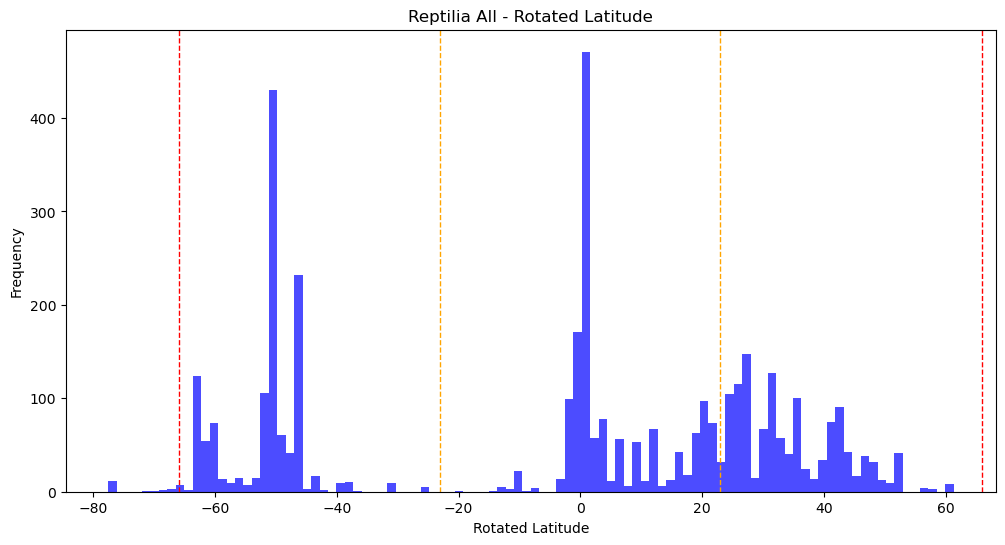

In [55]:
# Visualizing the latitudes, separately for Reptilia All and Synapsida
plt.figure(figsize=(12, 6))
plt.hist(reptilia_all_lats_filtered['Rotated latitude'], bins=100, color='blue', alpha=0.7)
# vertical lines at x = 66, 23, -23, -66
plt.axvline(x=66, color='red', linestyle='--', linewidth=1)
plt.axvline(x=23, color='orange', linestyle='--', linewidth=1)
plt.axvline(x=-23, color='orange', linestyle='--', linewidth=1)
plt.axvline(x=-66, color='red', linestyle='--', linewidth=1)
plt.title('Reptilia All - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.savefig('Perm-Trias/pt_data_visualizations/reptilia_all_widened_rotated_latitude_histogram.png')
plt.show()


In [133]:
explore_lats(reptilia_all_lats_filtered, 'Reptilia All Lats')

Exploring latitudes for Reptilia All Lats:

Number of unique genera in the Arctic biome, lat > 66
0

Number of unique genera on the cusp of the 66.5 degree line, 66 < lat < 67
0

Number of unique genera on the cusp of the 23.5 degree line, 23 < lat < 24
6

Latitude ranges of these cusp genera:
          genus       min       max  Occs on both sides of 23.5
0    Ammosaurus  23.76488  23.76488                       False
1  Bromsgroveia  23.39688  23.39688                        True
2   Clevosaurus  23.76488  23.76488                        True
3    Langeronyx  23.39688  23.39688                        True
4   Protosuchus  23.76488  23.76488                        True
5  Rhombopholis  23.39688  23.39688                        True

Number of unique genera on the cusp of the -23.5 degree line, -24 < lat < -23
0

Number of unique genera on the cusp of the -66.5 degree line, -67 < lat < -66
0

Number of unique genera in the Antarctic biome, lat <= -66
7


##### 23.5 Deg Cusp

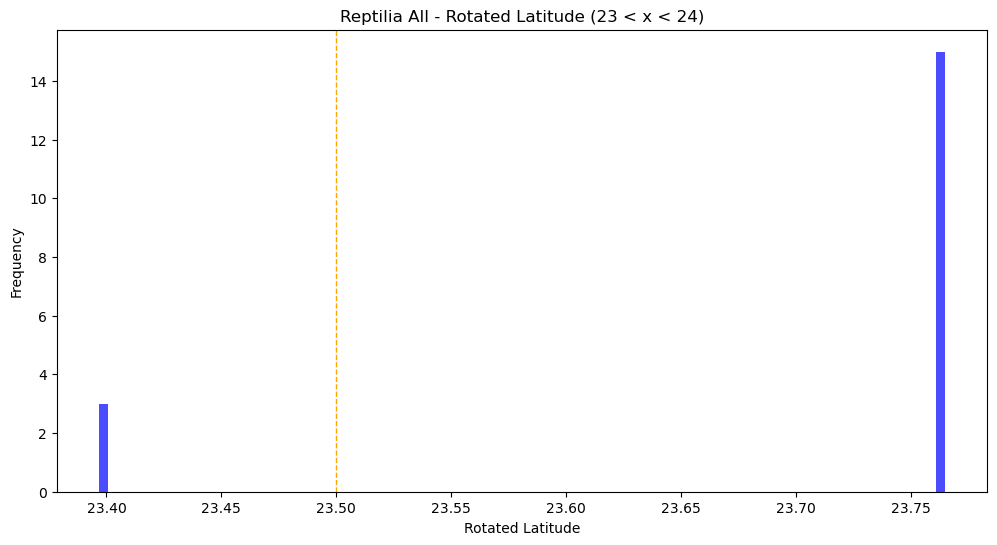

In [97]:
# Plot just reptilia all latitudes at 23 <= x <= 24, colored by genus
plt.figure(figsize=(12, 6))
plt.hist(reptilia_all_lats_filtered[(reptilia_all_lats_filtered['Rotated latitude'] >= 23) & (reptilia_all_lats_filtered['Rotated latitude'] <= 24)]['Rotated latitude'], bins=100, color='blue', alpha=0.7)
plt.title('Reptilia All - Rotated Latitude (23 < x < 24)')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.axvline(x=23.5, color='orange', linestyle='--', linewidth=1)
plt.show()

In [ ]:
def plot_latitude_in_chosen_range(df, y_range, y_value, title):   
    """Plot the distribution of Rotated Latitude by Genus."""
    filtered_df = df[(df['Rotated latitude'] >= y_range[0]) & (df['Rotated latitude'] <= y_range[1])]
    
    plt.figure(figsize=(8, 6))
    sns.stripplot(data=filtered_df, 
                  x='genus', 
                  y='Rotated latitude',
                  size=6,
                  alpha=0.7)
    
    plt.axhline(y=y_value, color='red', linestyle='--', linewidth=1, label=f'{y_value}° Line')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Genus')
    plt.ylabel('Rotated Latitude')
    plt.title(title)
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nSummary by genus:")
    summary = filtered_df.groupby('genus')['Rotated latitude'].agg(['count', 'mean', 'min', 'max'])
    print(summary)


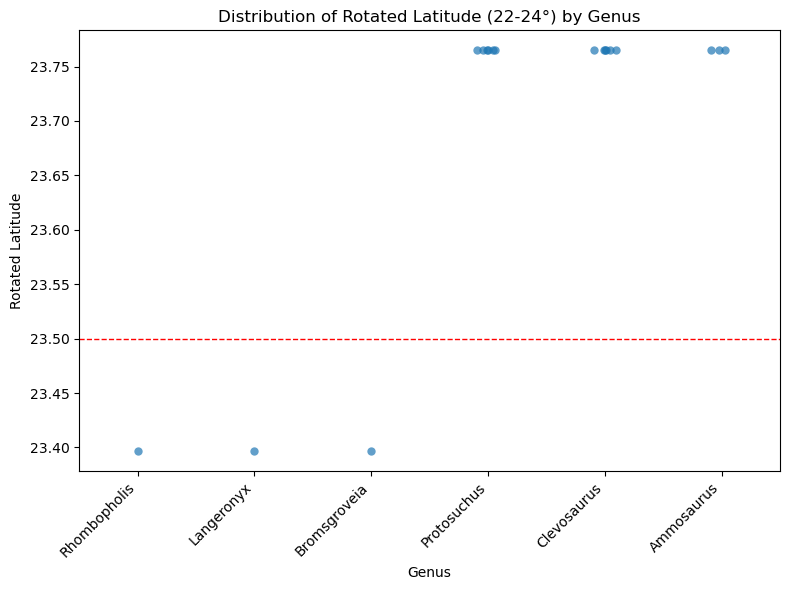


Summary by genus:
              count      mean       min       max
genus                                            
Ammosaurus        3  23.76488  23.76488  23.76488
Bromsgroveia      1  23.39688  23.39688  23.39688
Clevosaurus       6  23.76488  23.76488  23.76488
Langeronyx        1  23.39688  23.39688  23.39688
Protosuchus       6  23.76488  23.76488  23.76488
Rhombopholis      1  23.39688  23.39688  23.39688


In [96]:
plot_latitude_in_chosen_range(reptilia_all_lats_filtered, (23, 24), 23.5, 'Distribution of Rotated Latitude (22-24°) by Genus')

If these genera around the cusp also have an occurrence that is far on the other side of the dividing line, then their presence around the cusp of a line doesn't matter

In [110]:
reptilia_lats_by_genus = reptilia_all_lats_filtered.groupby('genus')['Rotated latitude'].agg(['count', 'mean', 'min', 'max']).sort_values(by='count', ascending=False)

In [109]:
reptilia_lats_by_genus[reptilia_lats_by_genus.index.isin(['Ammosaurus', 'Bromsgroveia', 'Clevosaurus', 'Langeronyx', 'Protosuchus', 'Rhombopholis'])]

,count,mean,min,max
genus,,,,
Clevosaurus,51,-10.003465,-49.477130,52.14119
Protosuchus,10,16.694395,6.088668,23.76488
Bromsgroveia,4,24.262117,23.396880,24.55053
Langeronyx,3,24.165980,23.396880,24.55053
Ammosaurus,3,23.764880,23.764880,23.76488
Rhombopholis,3,24.165980,23.396880,24.55053


##### -66.5 Cusp

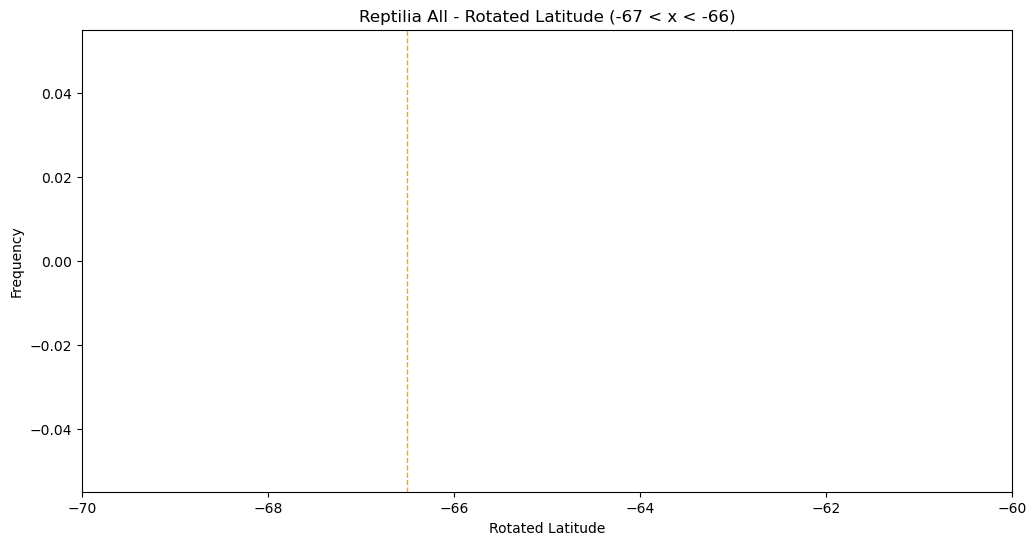

In [94]:
# Plot just reptilia all latitudes at -67 < x < -66, colored by genus
plt.figure(figsize=(12, 6))
plt.hist(reptilia_all_lats_filtered[(reptilia_all_lats_filtered['Rotated latitude'] >= -67) & (reptilia_all_lats_filtered['Rotated latitude'] <= -66)]['Rotated latitude'], bins=100, color='blue', alpha=0.7)
plt.title('Reptilia All - Rotated Latitude (-67 < x < -66)')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
# Limit x axis to -70 to -60
plt.xlim(-70, -60)
plt.axvline(x=-66.5, color='orange', linestyle='--', linewidth=1)
plt.show()

##### Widening "Cusp" Definition

In [135]:
def explore_lats_wider(df, name):
    print(f"Exploring wider latitudes for {name}:")

    print("\nNumber of unique genera on a wider cusp of the 66.5 degree line, 65.5 < lat < 67.5")
    wider_cusp_arctic_biome = df[(df['Rotated latitude'] >= 65.5) & (df['Rotated latitude'] <= 67.5)]
    wider_cusp_arctic_biome = wider_cusp_arctic_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']).reset_index()
    print(len(wider_cusp_arctic_biome))        
    # Do those genera on the cusp of the Arctic biome have occurrences on both sides of the 66.5 degree line?
    wider_cusp_arctic_biome['Occs on both sides of 66.5'] = False
    if len(wider_cusp_arctic_biome) > 0:
        wider_cusp_arctic_biome_genera = wider_cusp_arctic_biome['genus'].to_list()
        for genus in wider_cusp_arctic_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < 66.5 and occurrences['Rotated latitude'].max() > 66.5:
                wider_cusp_arctic_biome.loc[wider_cusp_arctic_biome['genus'] == genus, 'Occs on both sides of 66.5'] = True
            else:
                wider_cusp_arctic_biome.loc[wider_cusp_arctic_biome['genus'] == genus, 'Occs on both sides of 66.5'] = False
        print("\nLatitude ranges of these cusp genera:")
        print(wider_cusp_arctic_biome)
    

    print("\nNumber of unique genera on a wider cusp of the 23.5 degree line, 22.5 < lat < 24.5")
    wider_cusp_tropic_north_biome = df[(df['Rotated latitude'] >= 22.5) & (df['Rotated latitude'] <= 24.5)]
    wider_cusp_tropic_north_biome = wider_cusp_tropic_north_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']).reset_index()
    print(len(wider_cusp_tropic_north_biome))
    # Do those genera on the cusp of the Tropic of Cancer have occurrences on both sides of the 23.5 degree line?
    wider_cusp_tropic_north_biome['Occs on both sides of 23.5'] = False
    if len(wider_cusp_tropic_north_biome) > 0:
        wider_cusp_tropic_north_biome_genera = wider_cusp_tropic_north_biome['genus'].to_list()
        for genus in wider_cusp_tropic_north_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < 23.5 and occurrences['Rotated latitude'].max() > 23.5:
                wider_cusp_tropic_north_biome.loc[wider_cusp_tropic_north_biome['genus'] == genus, 'Occs on both sides of 23.5'] = True
            else:
                wider_cusp_tropic_north_biome.loc[wider_cusp_tropic_north_biome['genus'] == genus, 'Occs on both sides of 23.5'] = False
        print("\nLatitude ranges of these cusp genera:")
        print(wider_cusp_tropic_north_biome)


    print("\nNumber of unique genera on a wider cusp of the -23.5 degree line, -24.5 < lat < -22.5")
    wider_cusp_tropic_south_biome = df[(df['Rotated latitude'] >= -24.5) & (df['Rotated latitude'] <= -22.5)]
    wider_cusp_tropic_south_biome = wider_cusp_tropic_south_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']).reset_index()
    print(len(wider_cusp_tropic_south_biome))
    # Do those genera on the cusp of the Tropic of Capricorn have occurrences on both sides of the -23.5 degree line?
    wider_cusp_tropic_south_biome['Occs on both sides of -23.5'] = False
    if len(wider_cusp_tropic_south_biome) > 0:
        wider_cusp_tropic_south_biome_genera = wider_cusp_tropic_south_biome['genus'].to_list()
        for genus in wider_cusp_tropic_south_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < -23.5 and occurrences['Rotated latitude'].max() > -23.5:
                wider_cusp_tropic_south_biome.loc[wider_cusp_tropic_south_biome['genus'] == genus, 'Occs on both sides of -23.5'] = True
            else:
                wider_cusp_tropic_south_biome.loc[wider_cusp_tropic_south_biome['genus'] == genus, 'Occs on both sides of -23.5'] = False
        print("\nLatitude ranges of these cusp genera:")
        print(wider_cusp_tropic_south_biome)


    print("\nNumber of unique genera on a wider cusp of the -66.5 degree line, -67.5 < lat < -65.5")
    wider_cusp_antarctic_biome = df[(df['Rotated latitude'] >= -67.5) & (df['Rotated latitude'] <= -65.5)]
    wider_cusp_antarctic_biome = wider_cusp_antarctic_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']).reset_index()
    print(len(wider_cusp_antarctic_biome))
    # Do those genera on the cusp of the Antarctic Circle have occurrences on both sides of the -66.5 degree line?        
    wider_cusp_antarctic_biome['Occs on both sides of -66.5'] = False
    if len(wider_cusp_antarctic_biome) > 0:
        wider_cusp_antarctic_biome_genera = wider_cusp_antarctic_biome['genus'].to_list()
        for genus in wider_cusp_antarctic_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < -66.5 and occurrences['Rotated latitude'].max() > -66.5:
                wider_cusp_antarctic_biome.loc[wider_cusp_antarctic_biome['genus'] == genus, 'Occs on both sides of -66.5'] = True
            else:
                wider_cusp_antarctic_biome.loc[wider_cusp_antarctic_biome['genus'] == genus, 'Occs on both sides of -66.5'] = False
        print("\nLatitude ranges of these cusp genera:")
        print(wider_cusp_antarctic_biome)           


  

In [ ]:
def explore_lats_wider(df, name):
    print(f"Exploring latitudes for {name}:")


    print("Number of unique genera on the widened_cusp of the 66.5 degree line, 65.5 < lat < 67.5")
    widened_cusp_arctic_biome = df[(df['Rotated latitude'] >= 65.5) & (df['Rotated latitude'] <= 67.5)]
    print(len(widened_cusp_arctic_biome['genus'].unique()))
    plot_latitude_in_chosen_range(df, (65.5, 67.5), 66.5, 'Distribution of Rotated Latitude (65.5, 67.5°) by Genus')
    if len(widened_cusp_arctic_biome) > 0:
        print(widened_cusp_arctic_biome)
        print("\nLatitude ranges of these widened_cusp genera:")
        print(widened_cusp_arctic_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']))
    # Do those genera on the widened_cusp of the Arctic Circle have occurrences on both sides of the 66.5 degree line?
    if len(widened_cusp_arctic_biome) > 0:
        widened_cusp_arctic_biome_genera = widened_cusp_arctic_biome['genus'].unique()
        for genus in widened_cusp_arctic_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < 66.5 and occurrences['Rotated latitude'].max() > 66.5:
                print(f"{genus} has occurrences on both sides of the 66.5 degree line.")
            else:
                print(f"{genus} does NOT have occurrences on both sides of the 66.5 degree line.")
                      

    print("Number of unique genera on the widened_cusp of the 23.5 degree line, 22.5 < lat < 24.5")
    widened_cusp_tropic_north_biome = df[(df['Rotated latitude'] >= 22.5) & (df['Rotated latitude'] <= 24.5)]
    print(len(widened_cusp_tropic_north_biome['genus'].unique()))
    if len(widened_cusp_tropic_north_biome) > 0:
        print(widened_cusp_tropic_north_biome)
        print("\nLatitude ranges of these widened_cusp genera:")
        print(widened_cusp_tropic_north_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']))
    # Do those genera on the widened_cusp of the Tropic of Cancer have occurrences on both sides of the 23.5 degree line?
    if len(widened_cusp_tropic_north_biome) > 0:
        widened_cusp_tropic_north_biome_genera = widened_cusp_tropic_north_biome['genus'].unique()
        for genus in widened_cusp_tropic_north_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < 23.5 and occurrences['Rotated latitude'].max() > 23.5:
                print(f"{genus} has occurrences on both sides of the 23.5 degree line.")
            else:
                print(f"{genus} does NOT have occurrences on both sides of the 23.5 degree line.")


    print("Number of unique genera on the widened_cusp of the -23.5 degree line, -24.5 < lat < -22.5")
    widened_cusp_tropic_south_biome = df[(df['Rotated latitude'] >= -24.5) & (df['Rotated latitude'] <= -22.5)]
    print(len(widened_cusp_tropic_south_biome['genus'].unique()))
    if len(widened_cusp_tropic_south_biome) > 0:
        print(widened_cusp_tropic_south_biome)
        print("\nLatitude ranges of these widened_cusp genera:")
        print(widened_cusp_tropic_south_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']))
    # Do those genera on the widened_cusp of the Tropic of Capricorn have occurrences on both sides of the -23.5 degree line?
    if len(widened_cusp_tropic_south_biome) > 0:
        widened_cusp_tropic_south_biome['Occs on both sides of -23.5'] = False
        widened_cusp_tropic_south_biome_genera = widened_cusp_tropic_south_biome['genus'].unique()
        for genus in widened_cusp_tropic_south_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < -23.5 and occurrences['Rotated latitude'].max() > -23.5:
                print(f"{genus} has occurrences on both sides of the -23.5 degree line.")
                widened_cusp_tropic_south_biome.loc[widened_cusp_tropic_south_biome['genus'] == genus, 'Occs on both sides of -23.5'] = True
            else:
                print(f"{genus} does NOT have occurrences on both sides of the -23.5 degree line.")
                widened_cusp_tropic_south_biome.loc[widened_cusp_tropic_south_biome['genus'] == genus, 'Occs on both sides of -23.5'] = False


    print("Number of unique genera on the widened_cusp of the -66.5 degree line, -67.5 < lat < -65.5")
    widened_cusp_antarctic_biome = df[(df['Rotated latitude'] >= -67.5) & (df['Rotated latitude'] <= -65.5)]
    print(len(widened_cusp_antarctic_biome['genus'].unique()))
    if len(widened_cusp_antarctic_biome) > 0:
        print(widened_cusp_antarctic_biome)
        print("\nLatitude ranges of these widened_cusp genera:")
        print(widened_cusp_antarctic_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']))
    # Do those genera on the widened_cusp of the Antarctic Circle have occurrences on both sides of the -66.5 degree line?
    if len(widened_cusp_antarctic_biome) > 0:
        widened_cusp_antarctic_biome_genera = widened_cusp_antarctic_biome['genus'].unique()
        for genus in widened_cusp_antarctic_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < -66.5 and occurrences['Rotated latitude'].max() > -66.5:
                print(f"{genus} has occurrences on both sides of the -66.5 degree line.")
            else:
                print(f"{genus} does NOT have occurrences on both sides of the -66.5 degree line.")

    # If any of the above dataframes containing widened_cusp genera are >=1, print the rows in the dataframe that correspond to those genera

  

In [136]:
explore_lats_wider(reptilia_all_lats_filtered, 'Reptilia All Lats Wider')

Exploring wider latitudes for Reptilia All Lats Wider:

Number of unique genera on a wider cusp of the 66.5 degree line, 65.5 < lat < 67.5
0

Number of unique genera on a wider cusp of the 23.5 degree line, 22.5 < lat < 24.5
21

Latitude ranges of these cusp genera:
               genus       min       max  Occs on both sides of 23.5
0         Ammosaurus  23.76488  23.76488                       False
1        Amotosaurus  22.98052  22.98052                        True
2         Anomoiodon  22.98052  22.98052                        True
3       Bromsgroveia  23.39688  23.39688                        True
4        Clevosaurus  23.76488  23.76488                        True
5           Cyamodus  24.21337  24.21337                        True
6       Cymatosaurus  22.98052  24.48539                        True
7         Langeronyx  23.39688  23.39688                        True
8     Marcianosuchus  22.98052  22.98052                       False
9       Megachirella  24.48539  24.48539   

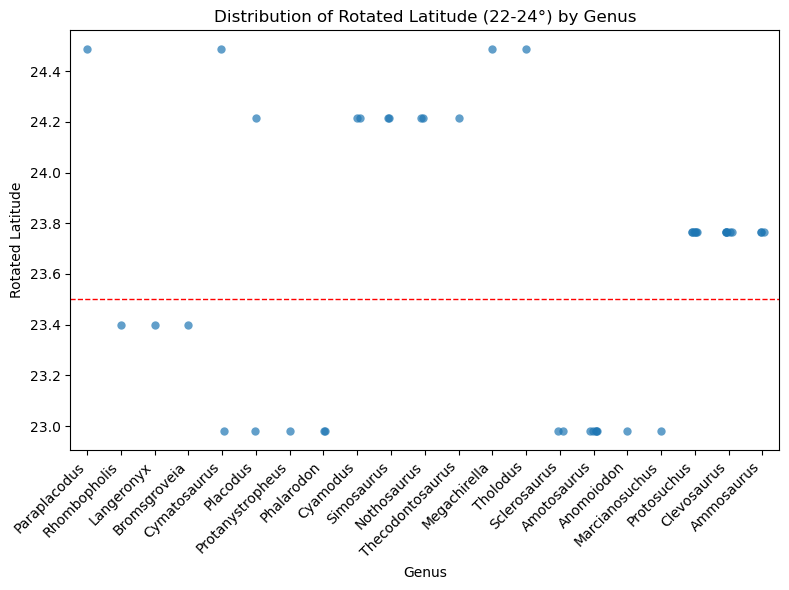


Summary by genus:
                  count       mean       min       max
genus                                                 
Ammosaurus            3  23.764880  23.76488  23.76488
Amotosaurus           5  22.980520  22.98052  22.98052
Anomoiodon            1  22.980520  22.98052  22.98052
Bromsgroveia          1  23.396880  23.39688  23.39688
Clevosaurus           6  23.764880  23.76488  23.76488
Cyamodus              2  24.213370  24.21337  24.21337
Cymatosaurus          2  23.732955  22.98052  24.48539
Langeronyx            1  23.396880  23.39688  23.39688
Marcianosuchus        1  22.980520  22.98052  22.98052
Megachirella          1  24.485390  24.48539  24.48539
Nothosaurus           2  24.213370  24.21337  24.21337
Paraplacodus          1  24.485390  24.48539  24.48539
Phalarodon            2  22.980520  22.98052  22.98052
Placodus              2  23.596945  22.98052  24.21337
Protanystropheus      1  22.980520  22.98052  22.98052
Protosuchus           6  23.764880  23.76488  

In [104]:
plot_latitude_in_chosen_range(reptilia_all_lats_filtered, (22.5, 24.5), 23.5, 'Distribution of Rotated Latitude (22-24°) by Genus')

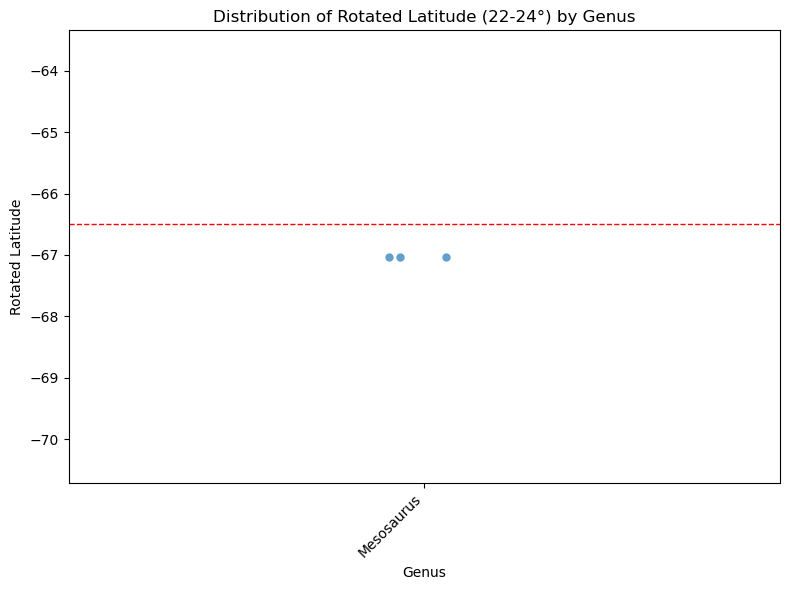


Summary by genus:
            count     mean      min      max
genus                                       
Mesosaurus      3 -67.0248 -67.0248 -67.0248


In [105]:
plot_latitude_in_chosen_range(reptilia_all_lats_filtered, (-67.5, -65.5), -66.5, 'Distribution of Rotated Latitude (22-24°) by Genus')

#### Synapsida Cusp

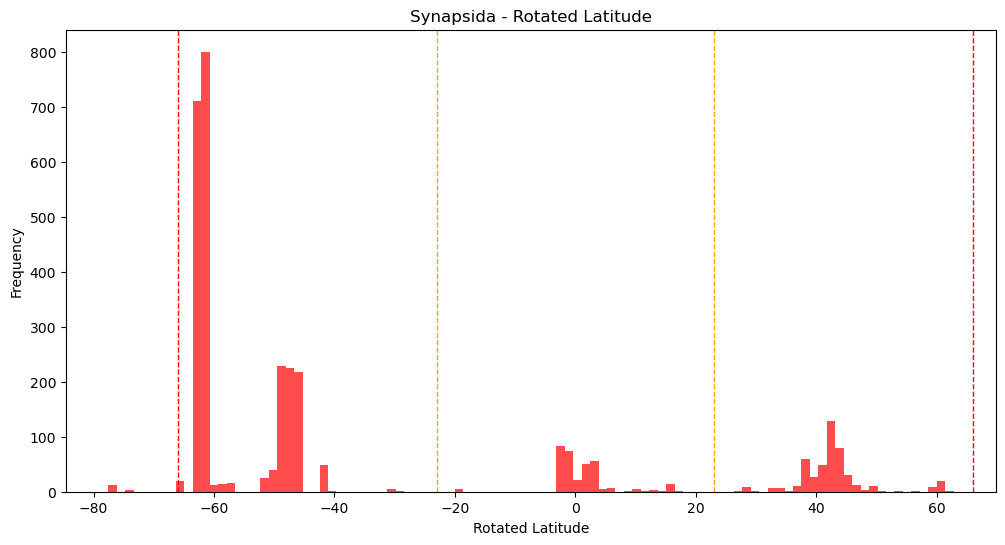

In [56]:
plt.figure(figsize=(12, 6))
plt.hist(synapsida_lats_filtered['Rotated latitude'], bins=100, color='red', alpha=0.7)
# vertical lines at x = 66, 23, -23, -66
plt.axvline(x=66, color='red', linestyle='--', linewidth=1)
plt.axvline(x=23, color='orange', linestyle='--', linewidth=1)
plt.axvline(x=-23, color='orange', linestyle='--', linewidth=1)
plt.axvline(x=-66, color='red', linestyle='--', linewidth=1)
plt.title('Synapsida - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.savefig('Perm-Trias/pt_data_visualizations/synapsida_widened_rotated_latitude_histogram.png')
plt.show()

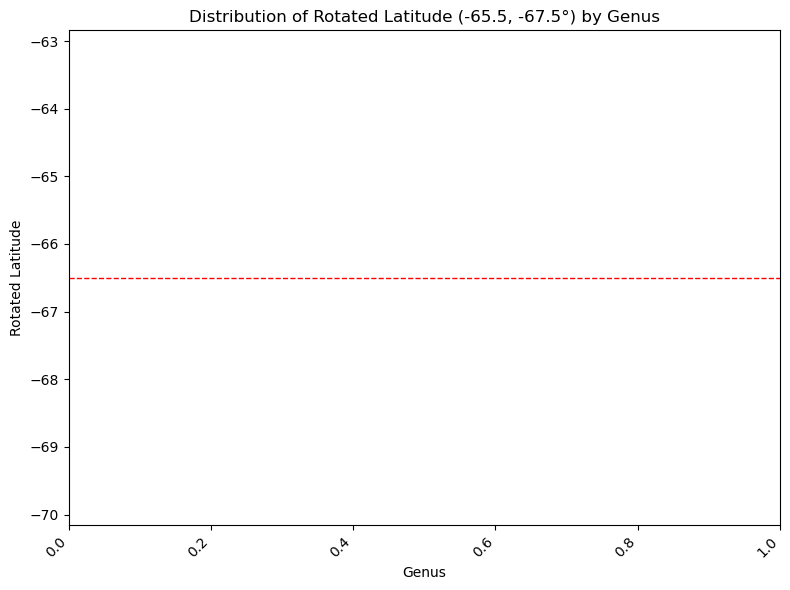


Summary by genus:
Empty DataFrame
Columns: [count, mean, min, max]
Index: []


In [140]:
plot_latitude_in_chosen_range(synapsida_lats_filtered, (-65.5, -67.5), -66.5, 'Distribution of Rotated Latitude (-65.5, -67.5°) by Genus')

In [138]:
explore_lats(synapsida_lats_filtered, 'Synapsida Lats')

Exploring latitudes for Synapsida Lats:

Number of unique genera in the Arctic biome, lat > 66
0

Number of unique genera on the cusp of the 66.5 degree line, 66 < lat < 67
0

Number of unique genera on the cusp of the 23.5 degree line, 23 < lat < 24
0

Number of unique genera on the cusp of the -23.5 degree line, -24 < lat < -23
0

Number of unique genera on the cusp of the -66.5 degree line, -67 < lat < -66
0

Number of unique genera in the Antarctic biome, lat <= -66
9


In [139]:
explore_lats_wider(synapsida_lats_filtered, 'Synapsida Lats Wider')

Exploring wider latitudes for Synapsida Lats Wider:

Number of unique genera on a wider cusp of the 66.5 degree line, 65.5 < lat < 67.5
0

Number of unique genera on a wider cusp of the 23.5 degree line, 22.5 < lat < 24.5
0

Number of unique genera on a wider cusp of the -23.5 degree line, -24.5 < lat < -22.5
0

Number of unique genera on a wider cusp of the -66.5 degree line, -67.5 < lat < -65.5
0


### Checking Lat Data Coverage

In [ ]:
# Check that all genuses in gl_reptilia_all, gl_reptilia_terr, gl_synapsida, and pt_reptilia_terr are in the latitude data predictor file

# Create list of all unique genera in gl_reptilia_all, gl_reptilia_terr, gl_synapsida, and pt_reptilia_terr, then compare to the list of genera 
# in the latitude data predictor file

## Time-Series Data (Isotopic)

In [225]:
songEA_data = pd.read_csv("Guad-Ladin/PaleoEnvData_Stage_SongEA_Guad-Lad.csv")
songEA_data.head()

,Period,Stage,age,mean,Mod_R_deltaTMyr
0,Permian,Roadian,270.5,27.775300,1.532881
1,Permian,Sakmarian,292.0,26.797336,1.676262
2,Permian,Wordian,265.5,25.249696,2.204013
3,Permian,Wuchipiangian,257.0,29.064592,1.262948
4,Triassic,Anisian,244.0,34.241650,1.815053


In [226]:
songEA_data.rename(columns={'age': 'Time'}, inplace=True)
songEA_data

,Period,Stage,Time,mean,Mod_R_deltaTMyr
0,Permian,Roadian,270.50,27.775300,1.532881
1,Permian,Sakmarian,292.00,26.797336,1.676262
2,Permian,Wordian,265.50,25.249696,2.204013
3,Permian,Wuchipiangian,257.00,29.064592,1.262948
4,Triassic,Anisian,244.00,34.241650,1.815053
5,Triassic,Carnian,232.25,32.130069,1.418901
6,Triassic,Induan,250.50,36.701308,2.291109
7,Triassic,Ladinian,239.00,33.490617,2.078977


In [227]:
# The row order needs to be smallest to largest by 'Time'
songEA_data_ordered = songEA_data.sort_values(by='Time').reset_index(drop=True)

#### Z-transformation

In [228]:
# Z transforming both columns
from sklearn.preprocessing import StandardScaler
scaler_mean = StandardScaler()
songEA_data_ordered['mean_z_trans'] = scaler_mean.fit_transform(songEA_data_ordered[['mean']])
scaler_Mod = StandardScaler()
songEA_data_ordered['Mod_R_deltaTMyr_z_trans'] = scaler_Mod.fit_transform(songEA_data_ordered[['Mod_R_deltaTMyr']])

songEA_data_ordered

,Period,Stage,Time,mean,Mod_R_deltaTMyr,mean_z_trans,Mod_R_deltaTMyr_z_trans
0,Triassic,Carnian,232.25,32.130069,1.418901,0.382854,-1.035019
1,Triassic,Ladinian,239.00,33.490617,2.078977,0.742399,0.831026
2,Triassic,Anisian,244.00,34.241650,1.815053,0.940871,0.084911
3,Triassic,Induan,250.50,36.701308,2.291109,1.590874,1.430728
4,Permian,Wuchipiangian,257.00,29.064592,1.262948,-0.427245,-1.475899
5,Permian,Wordian,265.50,25.249696,2.204013,-1.435390,1.184505
6,Permian,Roadian,270.50,27.775300,1.532881,-0.767961,-0.712796
7,Permian,Sakmarian,292.00,26.797336,1.676262,-1.026402,-0.307456


In [229]:
songEA_data_ordered.rename(columns={'age':'Time'}, inplace=True)
songEA_data_ordered_filtered = songEA_data_ordered[['Time', 'mean_z_trans', 'Mod_R_deltaTMyr_z_trans']]
songEA_data_ordered_filtered

,Time,mean_z_trans,Mod_R_deltaTMyr_z_trans
0,232.25,0.382854,-1.035019
1,239.00,0.742399,0.831026
2,244.00,0.940871,0.084911
3,250.50,1.590874,1.430728
4,257.00,-0.427245,-1.475899
5,265.50,-1.435390,1.184505
6,270.50,-0.767961,-0.712796
7,292.00,-1.026402,-0.307456


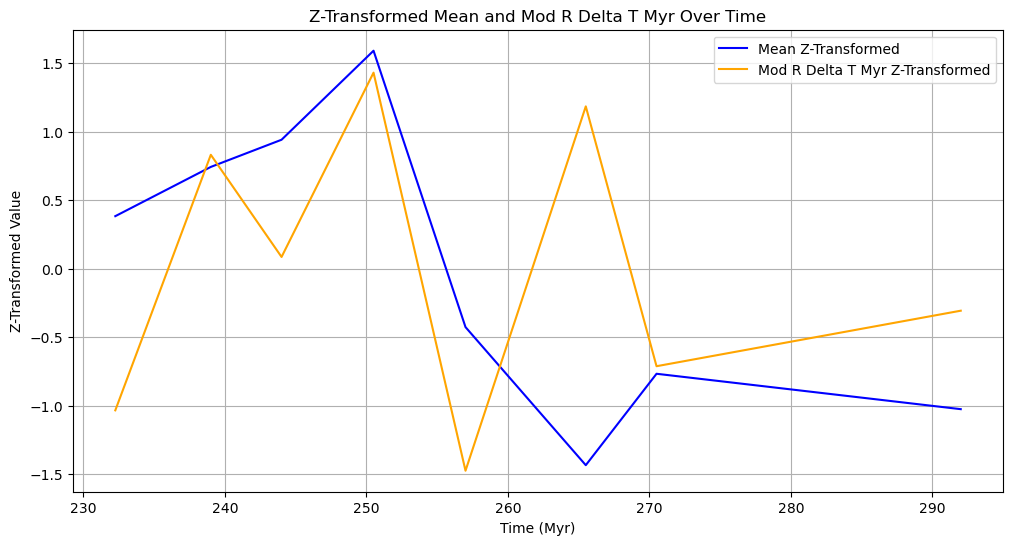

In [230]:
# Plotting the distribution of the mean_z_trans and Mod_R_deltaTMyr_z_trans columns as line plots
plt.figure(figsize=(12, 6))
plt.plot(songEA_data_ordered_filtered['Time'], songEA_data_ordered_filtered['mean_z_trans'], label='Mean Z-Transformed', color='blue')
plt.plot(songEA_data_ordered_filtered['Time'], songEA_data_ordered_filtered['Mod_R_deltaTMyr_z_trans'], label='Mod R Delta T Myr Z-Transformed', color='orange')
plt.title('Z-Transformed Mean and Mod R Delta T Myr Over Time')
plt.xlabel('Time (Myr)')
plt.ylabel('Z-Transformed Value')
plt.legend()
plt.grid()
plt.savefig('Guad-Ladin/gl_data_visualizations/songEA_z_transformed_plot.png')
plt.show()
                                                                            

In [ ]:
songEA_data_ordered_filtered.to_csv("Guad-Ladin/songEA_isotopic_data/songEA_data_ordered_filtered.txt", sep="\t", index=False)

#### Adding to Backscale.txt

In [272]:
# create a new column in reptilia_all_backscale called 'mean_z_trans'
# Should contain the mean and std of the original 'mean' column from songEA_data_ordered

reptilia_all_backscale, synapsida_backscale

(   lat_range_z_trans
 0           4.474401
 1          13.293794,
    lat_range_z_trans
 0           4.733017
 1          15.930623)

In [273]:
reptilia_all_backscale['mean_z_trans'] = [songEA_data_ordered['mean'].mean(), songEA_data_ordered['mean'].std()]
reptilia_all_backscale['Mod_R_deltaTMyr_z_trans'] = [songEA_data_ordered['Mod_R_deltaTMyr'].mean(), songEA_data_ordered['Mod_R_deltaTMyr'].std()]
synapsida_backscale['mean_z_trans'] = [songEA_data_ordered['mean'].mean(), songEA_data_ordered['mean'].std()] 
synapsida_backscale['Mod_R_deltaTMyr_z_trans'] = [songEA_data_ordered['Mod_R_deltaTMyr'].mean(), songEA_data_ordered['Mod_R_deltaTMyr'].std()]



In [274]:
reptilia_all_backscale

,lat_range_z_trans,mean_z_trans,Mod_R_deltaTMyr_z_trans
0,4.474401,30.681321,1.785018
1,13.293794,4.045348,0.378153


In [ ]:
# in backscale, syn and rep mean and mod values should be the same, lat values should be different
synapsida_backscale

,lat_range_z_trans,mean_z_trans,Mod_R_deltaTMyr_z_trans
0,4.733017,30.681321,1.785018
1,15.930623,4.045348,0.378153


In [276]:
# Saving for now
reptilia_all_backscale.to_csv("Perm-Trias/reptilia_all_backscale.txt", sep="\t", index=False)
synapsida_backscale.to_csv("Perm-Trias/synapsida_backscale.txt", sep="\t", index=False)

## Time-Series Data (BRIDGE)

#### Z-transformation

#### Adding to Backscale.txt